# CodeSearchNet Dataset Exploration — Code Copilot (RAG + LoRA + Agent)

This notebook explores **CodeSearchNet (Python subset)** as the dataset for a new,
from-scratch experiment, for the purpose of planning the preprocessing stage of the project.

**What this notebook checks:**
1. Loading the dataset and its size
2. Structure of a single record (available fields)
3. Length statistics (code / docstring) — charts
4. Distribution by repository — charts
5. Documentation quality/noise (empty docstrings, too-short docstrings, etc.)
6. Token-level length check (real tokenizer, not just chars/words)
7. Documentation language check (is it actually English?)
8. Near-duplicate code check on the full dataset (not just the sample)
9. Manual spot-check of "good by the stats" examples
10. Conclusions for planning the preprocessing (chunking, filtering, embeddings)

**Dataset:** [`claudios/code_search_net`](https://huggingface.co/datasets/claudios/code_search_net)
— an unofficial reupload in parquet format of the original corpus (Husain et al., 2019),
which loads faster than the original version (which requires running a loading script).
There is also a fallback to the official version `code-search-net/code_search_net`
if the first one is unavailable.

> Recommended runtime: Colab, no GPU required for this exploration stage (CPU is enough).


> ### ⚠️ This version needs a full re-run from the top
> This revision increases `SAMPLE_SIZE` (Step 3) and `CORPUS_SIZE` /
> `QUERY_SAMPLE_SIZE` (Step 14) to work toward RAG-readiness Gates 3 and 4
> (see the **RAG-Readiness Scorecard** at the very end of the notebook), and
> adds two new sections at the end (automated large-scale paraphrase testing,
> and an end-to-end generation+judge check). All previously-computed outputs
> have been cleared since they no longer match these parameters. Run the
> notebook top to bottom in a **GPU runtime** (Runtime → Change runtime type)
> - encoding 60k+ code snippets on CPU will be slow.


## Step 0: Installation and loading

In [1]:
!pip install -q datasets pandas matplotlib pyarrow


In [2]:
from datasets import load_dataset
import pandas as pd

# First attempt: fast parquet reupload
try:
    ds = load_dataset("claudios/code_search_net", "python")
    source_used = "claudios/code_search_net (parquet reupload)"
except Exception as e:
    print("Failed to load claudios/code_search_net, falling back to the official version...")
    print(e)
    ds = load_dataset("code-search-net/code_search_net", "python", trust_remote_code=True)
    source_used = "code-search-net/code_search_net (official)"

print("Source actually loaded:", source_used)
print(ds)


README.md:   0%|          | 0.00/13.6k [00:00<?, ?B/s]

python/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  130MB            

python/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

python/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  135MB            

python/train-00001-of-00003.parquet: downloading bytes:           |  0.00B            

...

python/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/412178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/23107 [00:00<?, ? examples/s]

Source actually loaded: claudios/code_search_net (parquet reupload)
DatasetDict({
    train: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_documentation_string', 'func_code_url'],
        num_rows: 412178
    })
    test: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_documentation_string', 'func_code_url'],
        num_rows: 22176
    })
    validation: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_documentation_string', 'func_code_url'],
        num_rows: 23107
    })
})


## Step 1: Dataset size

Checking how many examples exist in each split (train/validation/test) — to plan how
much time/resources will be needed for the embedding and chunking stage.


In [3]:
sizes = {split: len(ds[split]) for split in ds.keys()}
sizes_df = pd.DataFrame(list(sizes.items()), columns=["split", "num_examples"])
sizes_df["percent"] = (sizes_df["num_examples"] / sizes_df["num_examples"].sum() * 100).round(1)
sizes_df


,split,num_examples,percent
0,train,412178,90.1
1,test,22176,4.8
2,validation,23107,5.1


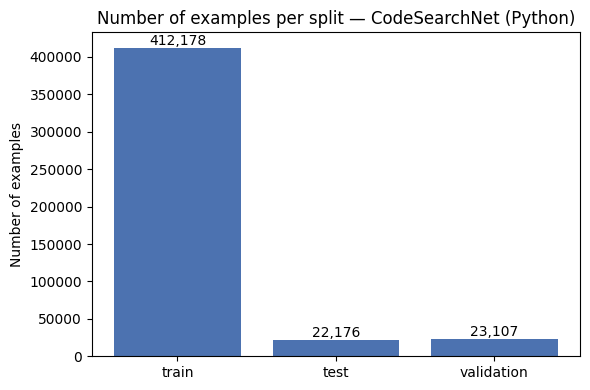

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(sizes_df["split"], sizes_df["num_examples"], color="#4C72B0")
ax.set_title("Number of examples per split — CodeSearchNet (Python)")
ax.set_ylabel("Number of examples")
for i, v in enumerate(sizes_df["num_examples"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## Step 2: Structure of a single record

Checking which fields actually exist in a record, to know what's available for RAG
(code, documentation, file path, repository).


In [5]:
example = ds["train"][0]
for k, v in example.items():
    preview = str(v)
    if len(preview) > 200:
        preview = preview[:200] + " ...[truncated]"
    print(f"{k!r}:\n  {preview}\n")


'repository_name':
  proycon/pynlpl

'func_path_in_repository':
  pynlpl/formats/folia.py

'func_name':
  AbstractElement.addidsuffix

'whole_func_string':
  def addidsuffix(self, idsuffix, recursive = True):
        """Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked imp ...[truncated]

'language':
  python

'func_code_string':
  def addidsuffix(self, idsuffix, recursive = True):
        """Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked imp ...[truncated]

'func_documentation_string':
  Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked implicitly by :meth:`copy`

'func_code_url':
  https://github.com/proycon/pynlpl/blob/7707f69a91caaa6cde037f0d0379f1d42500a68b/pynlpl/formats/folia.py#L1263-L1271



## Step 3: Convert to a DataFrame for analysis (sample)

For a quick check, we take a sample (e.g. 20,000 rows from train) instead of the full
dataset — this is enough for statistical analysis and much faster than loading
everything into memory.


In [6]:
# Bumped from 20,000 -> 100,000: Gate 4 (RAG-Readiness Scorecard, end of
# notebook) needs retrieval checked closer to production scale, and Gate 3
# (hard negatives) needs enough same-file/same-repo candidates to have teeth.
SAMPLE_SIZE = 100000
train_sample = ds["train"].shuffle(seed=42).select(range(min(SAMPLE_SIZE, len(ds["train"]))))
df = train_sample.to_pandas()

# Useful length columns for the analysis
code_col = "func_code_string" if "func_code_string" in df.columns else "whole_func_string"
doc_col = "func_documentation_string"
repo_col = "repository_name" if "repository_name" in df.columns else "repo"

df["code_len_chars"] = df[code_col].astype(str).str.len()
df["code_len_lines"] = df[code_col].astype(str).str.count("\n") + 1
df["doc_len_chars"] = df[doc_col].astype(str).str.len()
df["doc_len_words"] = df[doc_col].astype(str).str.split().str.len()

df[[code_col, doc_col, repo_col, "code_len_chars", "code_len_lines", "doc_len_chars", "doc_len_words"]].head()


,func_code_string,func_documentation_string,repository_name,code_len_chars,code_len_lines,doc_len_chars,doc_len_words
0,"def send_text_card(self, agent_id, user_ids, t...",文本卡片消息\n\n https://work.weixin.qq.com/a...,jxtech/wechatpy,1736,51,1181,74
1,"def get_group(self, name, user_name=None):\n ...",Get information on the given group or whether ...,jhuapl-boss/intern,686,19,489,63
2,"def dispatch(self, test=False): # pylint: dis...",Send configuration to satellites\n\n :r...,Alignak-monitoring/alignak,3655,106,55,6
3,"def cursor(self, status):\n """"""Turn und...",Turn underline cursor visibility on/off,PedalPi/Raspberry-Physical,225,4,39,5
4,"def is_contradictory(self, other):\n """"...",Can these two strings coexist ?,EventTeam/beliefs,537,16,31,6


## Step 3b: Removing docstring leakage from the code field (before embedding)

**Why this step exists:** in CodeSearchNet, a function's docstring is not only
stored separately in `func_documentation_string` — it is *also* physically
embedded inside `func_code_string` / `whole_func_string`, because in Python the
docstring is literally the first statement in the function body (see the raw
example printed in Step 2). That means if we build retrieval embeddings
directly on `func_code_string`, we are embedding a string that already
contains a near-verbatim copy of the very documentation we'll later use as the
query. Any retrieval score computed that way is partly measuring "does this
docstring match a near-copy of itself inside the code", not "does this model
understand what the code does" — a form of data leakage.

This matters concretely for this notebook: it is the most likely explanation
for why the plain-lexical BM25 baseline in Step 15b outperforms the
sentence-embedding model (98.0% vs 91.0% Hit@1) — BM25 is very good at
finding near-exact word overlap, and the docstring sitting inside the "code"
field hands it exactly that.

**The fix:** build a `code_clean` column with the docstring removed from the
function body (using Python's `ast` module to find and delete exactly the
docstring statement, falling back to the original text unchanged if a
function fails to parse — e.g. Python-2-only syntax). `code_clean` is what
Step 14 onward should embed and index, instead of the raw `code_col`.
`func_documentation_string` (`doc_col`) is untouched and remains the source of
queries, so code and documentation are now genuinely independent signals.

> **Action needed:** this cell only adds the `code_clean` column and a few
> spot-checks — it does not by itself change any already-computed results.
> Step 14 (baseline retrieval) and Step 15b (BM25) below have been updated to
> read from `code_clean` instead of `code_col`. Every downstream cell that
> reuses their embeddings/results (Steps 15, 15c, 15c-v2, 15d, 15e) will
> automatically reflect the fix once the notebook is re-run from Step 14
> onward — their currently-displayed numbers/charts are from *before* this
> fix and are now stale until re-executed.


In [7]:
import ast

def strip_docstring(code_str):
    """Return `code_str` with the function's docstring statement removed,
    preserving the original formatting/whitespace of everything else.

    Uses `ast` to find the *outermost* function/class definition's first
    statement and check whether it is a bare string literal (a docstring).
    If so, the exact source lines that statement spans are deleted from the
    raw text. If the snippet can't be parsed at all (e.g. Python 2 syntax,
    a stray fragment), or has no leading docstring, the original text is
    returned unchanged - this is a best-effort transform, not a guarantee,
    so it deliberately fails safe rather than raising.
    """
    try:
        tree = ast.parse(code_str)
    except (SyntaxError, ValueError):
        return code_str

    for node in ast.walk(tree):
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)):
            if not node.body:
                break
            first = node.body[0]
            value = getattr(first, "value", None)
            is_const_str = isinstance(value, ast.Constant) and isinstance(value.value, str)
            is_legacy_str = isinstance(value, getattr(ast, "Str", ()))  # py<3.8 compat, harmless on 3.8+
            if isinstance(first, ast.Expr) and (is_const_str or is_legacy_str):
                lines = code_str.splitlines(keepends=True)
                start_line = first.lineno - 1
                end_line = getattr(first, "end_lineno", first.lineno) - 1
                del lines[start_line:end_line + 1]
                return "".join(lines)
            break  # only inspect the outermost def/class - one function per record
    return code_str


df["code_clean"] = df[code_col].astype(str).apply(strip_docstring)

n_total = len(df)
n_changed = (df["code_clean"] != df[code_col].astype(str)).sum()
print(f"Docstring successfully stripped from {n_changed:,} / {n_total:,} functions "
      f"({n_changed / n_total * 100:.1f}%). The remainder either failed to parse "
      "(e.g. Python 2 syntax) or genuinely had no leading docstring, and were left unchanged.")

# Spot-check a couple of rows side by side to confirm the docstring is gone
# but the rest of the function body is untouched.
for _, r in df[df["code_clean"] != df[code_col].astype(str)].sample(2, random_state=0).iterrows():
    print("\n=== BEFORE (code_col) ===")
    print(r[code_col][:300])
    print("\n=== AFTER (code_clean) ===")
    print(r["code_clean"][:300])
    print("=" * 60)


/tmp/ipykernel_6578/1850111389.py:27: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  is_legacy_str = isinstance(value, getattr(ast, "Str", ()))  # py<3.8 compat, harmless on 3.8+
<unknown>:16: SyntaxWarning: invalid escape sequence '\ '
<unknown>:29: SyntaxWarning: invalid escape sequence '\m'
<unknown>:5: SyntaxWarning: invalid escape sequence '\*'
<unknown>:7: SyntaxWarning: invalid escape sequence '\d'
<unknown>:6: SyntaxWarning: invalid escape sequence '\*'
<unknown>:35: SyntaxWarning: invalid escape sequence '\g'
<unknown>:8: SyntaxWarning: invalid escape sequence '\*'
<unknown>:10: SyntaxWarning: invalid escape sequence '\e'
<unknown>:12: SyntaxWarning: invalid escape sequence '\d'
<unknown>:3: SyntaxWarning: invalid escape sequence '\d'
<unknown>:10: SyntaxWarning: invalid escape sequence '\g'
<unknown>:3: SyntaxWarning: invalid escape sequence '\~'
<unknown>:11: SyntaxWarning: invalid escape sequence '\('
<unknown>:77: S

Docstring successfully stripped from 98,889 / 100,000 functions (98.9%). The remainder either failed to parse (e.g. Python 2 syntax) or genuinely had no leading docstring, and were left unchanged.

=== BEFORE (code_col) ===
def set_mem_per_proc(self, mem_mb):
        """Set the memory per process in megabytes"""
        super().set_mem_per_proc(mem_mb)
        self.qparams["mem_per_slot"] = str(int(self.mem_per_proc)) + "M"

=== AFTER (code_clean) ===
def set_mem_per_proc(self, mem_mb):
        super().set_mem_per_proc(mem_mb)
        self.qparams["mem_per_slot"] = str(int(self.mem_per_proc)) + "M"

=== BEFORE (code_col) ===
def gof_plot(
    simdata, trueval, name=None, bins=None, format='png', suffix='-gof', path='./',
        fontmap=None, verbose=0):
    """
    Plots histogram of replicated data, indicating the location of the observed data

    :Arguments:
        simdata: array or PyMC object
            Trace of

=== AFTER (code_clean) ===
def gof_plot(
    simdata, trueval, na

<unknown>:10: SyntaxWarning: invalid escape sequence '\m'
<unknown>:23: SyntaxWarning: invalid escape sequence '\['
<unknown>:5: SyntaxWarning: invalid escape sequence '\.'
<unknown>:6: SyntaxWarning: invalid escape sequence '\<'
<unknown>:8: SyntaxWarning: invalid escape sequence '\>'
<unknown>:2: SyntaxWarning: invalid escape sequence '\c'
<unknown>:9: SyntaxWarning: invalid escape sequence '\D'
<unknown>:9: SyntaxWarning: invalid escape sequence '\D'
<unknown>:10: SyntaxWarning: invalid escape sequence '\D'
<unknown>:15: SyntaxWarning: invalid escape sequence '\s'
<unknown>:15: SyntaxWarning: invalid escape sequence '\s'
<unknown>:21: SyntaxWarning: invalid escape sequence '\s'
<unknown>:22: SyntaxWarning: invalid escape sequence '\s'
<unknown>:26: SyntaxWarning: invalid escape sequence '\s'
<unknown>:27: SyntaxWarning: invalid escape sequence '\s'
<unknown>:30: SyntaxWarning: invalid escape sequence '\$'
<unknown>:31: SyntaxWarning: invalid escape sequence '\$'
<unknown>:33: Syntax

## Step 4: Code length distribution (for chunking planning)

Function length determines a reasonable chunk size — embedding models are typically limited to 256-512 tokens, so this needs to be grounded in the actual distribution rather than assumed.


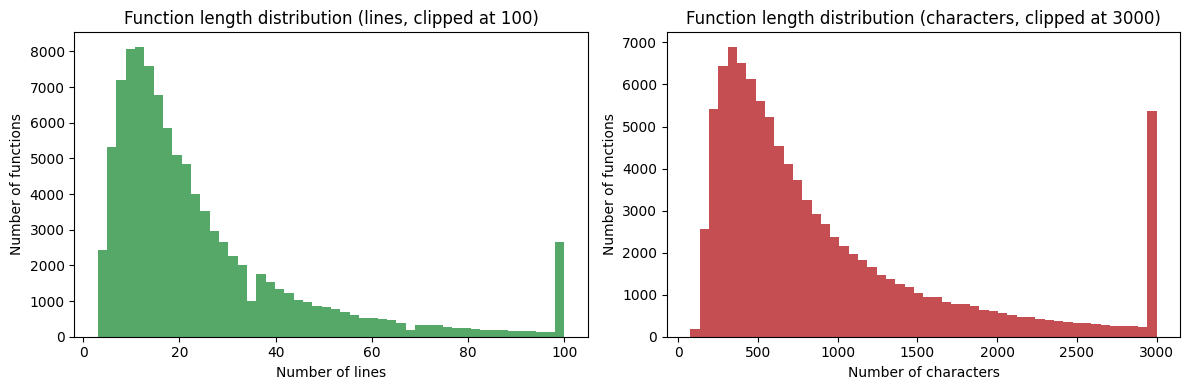

count    100000.000000
mean         26.708580
std          32.414855
min           3.000000
25%          11.000000
50%          18.000000
75%          31.000000
max        2773.000000
Name: code_len_lines, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["code_len_lines"].clip(upper=100), bins=50, color="#55A868")
axes[0].set_title("Function length distribution (lines, clipped at 100)")
axes[0].set_xlabel("Number of lines")
axes[0].set_ylabel("Number of functions")

axes[1].hist(df["code_len_chars"].clip(upper=3000), bins=50, color="#C44E52")
axes[1].set_title("Function length distribution (characters, clipped at 3000)")
axes[1].set_xlabel("Number of characters")
axes[1].set_ylabel("Number of functions")

plt.tight_layout()
plt.show()

print(df["code_len_lines"].describe())


## Step 5: Documentation length distribution (for prompt/response planning for LoRA)

Docstrings that are too short (0-2 words) are usually not useful as an "answer" for
LoRA training — they should be filtered out.


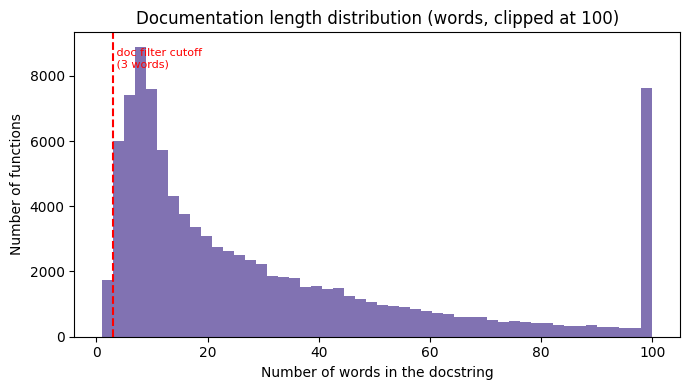

count    100000.000000
mean         37.719090
std          69.705807
min           1.000000
25%           9.000000
50%          19.000000
75%          43.000000
max        6371.000000
Name: doc_len_words, dtype: float64

Docstrings at or below the 3-word filter cutoff: 4,647 out of 100,000 (4.6%)


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["doc_len_words"].clip(upper=100), bins=50, color="#8172B2")
ax.set_title("Documentation length distribution (words, clipped at 100)")
ax.set_xlabel("Number of words in the docstring")
ax.set_ylabel("Number of functions")

# Mark where the MIN_DOC_WORDS filter (used later in Step 17's preprocessing decisions)
# actually cuts the distribution, so the histogram doubles as a preview of how much of
# the left tail that filter removes.
FILTER_PREVIEW_MIN_DOC_WORDS = 3
ax.axvline(FILTER_PREVIEW_MIN_DOC_WORDS, color="red", linestyle="--", linewidth=1.5)
ax.text(
    FILTER_PREVIEW_MIN_DOC_WORDS, ax.get_ylim()[1] * 0.95,
    f" doc filter cutoff\n ({FILTER_PREVIEW_MIN_DOC_WORDS} words)",
    color="red", ha="left", va="top", fontsize=8,
)

plt.tight_layout()
plt.show()

print(df["doc_len_words"].describe())

# How many docstrings are "too thin" (<= FILTER_PREVIEW_MIN_DOC_WORDS words) vs. valid ones
thin_doc = (df["doc_len_words"] <= FILTER_PREVIEW_MIN_DOC_WORDS).sum()
print(f"\nDocstrings at or below the {FILTER_PREVIEW_MIN_DOC_WORDS}-word filter cutoff: "
      f"{thin_doc:,} out of {len(df):,} ({thin_doc/len(df)*100:.1f}%)")


## Step 6: Distribution by repository

Checking how many distinct repositories exist in the sample, and how concentrated the
functions are in a few large repositories (long-tail) — this affects the decision of
which repositories to pick as examples for RAG.


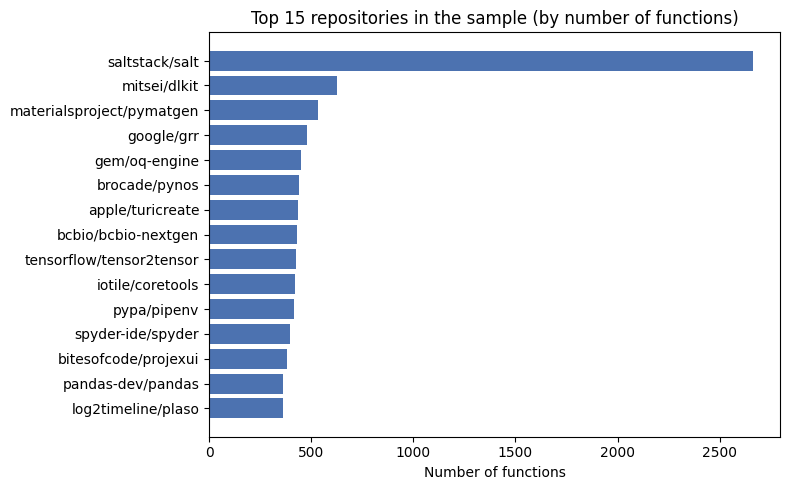

Number of unique repositories in the sample: 9,647


In [10]:
top_repos = df[repo_col].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_repos.index[::-1], top_repos.values[::-1], color="#4C72B0")
ax.set_title("Top 15 repositories in the sample (by number of functions)")
ax.set_xlabel("Number of functions")
plt.tight_layout()
plt.show()

n_unique_repos = df[repo_col].nunique()
print(f"Number of unique repositories in the sample: {n_unique_repos:,}")


## Step 7: Checking "noise" — functions without useful documentation

Some functions in CodeSearchNet come with an empty docstring, a placeholder, or one
that's too short ("TODO", "See above", etc.). These will hurt both RAG (irrelevant
retrieval) and LoRA (poor-quality answers). Checking the expected noise percentage.


In [11]:
# NOTE: duplicate_code here is measured on the 20K sample only. With ~412K functions
# in the full train split, exact-string duplication on a 20K sample understates the
# real overlap (many repos reuse boilerplate). Treat this number as a lower bound —
# see Step 11 below for a proper full-scale exact + near-duplicate check.
empty_doc = df[doc_col].astype(str).str.strip().eq("").sum()
very_short_doc = (df["doc_len_words"] <= 2).sum()
duplicate_code = df[code_col].duplicated().sum()

quality_stats = pd.DataFrame({
    "metric": ["Empty documentation", "Documentation shorter than 2 words", "Duplicate code (20K sample only, lower bound)"],
    "count": [empty_doc, very_short_doc, duplicate_code],
    "percent": [round(x / len(df) * 100, 2) for x in [empty_doc, very_short_doc, duplicate_code]],
})
quality_stats


,metric,count,percent
0,Empty documentation,0,0.00
1,Documentation shorter than 2 words,1747,1.75
2,"Duplicate code (20K sample only, lower bound)",0,0.00


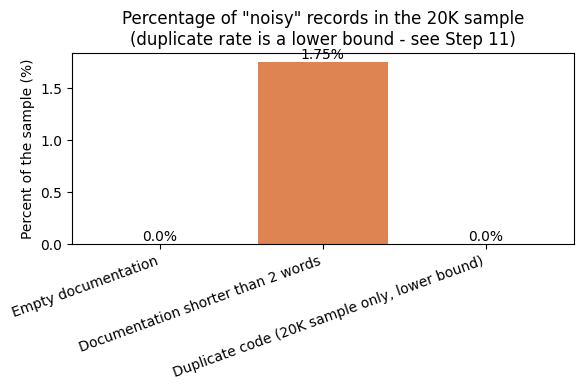

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(quality_stats["metric"], quality_stats["percent"], color="#DD8452")
ax.set_title("Percentage of \"noisy\" records in the 20K sample\n(duplicate rate is a lower bound - see Step 11)")
ax.set_ylabel("Percent of the sample (%)")
plt.xticks(rotation=20, ha="right")
for i, v in enumerate(quality_stats["percent"]):
    ax.text(i, v, f"{v}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## Step 8: A full example of a valid record (to understand the prompt/response)

Showing one example with valid documentation — as it would actually be used for a
(prompt, response) pair for LoRA training, and to see what a chunk would look like in RAG.


In [13]:
good_examples = df[df["doc_len_words"] > 8].sample(1, random_state=1)
row = good_examples.iloc[0]

print("=== Repository ===")
print(row[repo_col])
print("\n=== Documentation (will be part of the 'answer' / query) ===")
print(row[doc_col])
print("\n=== Code (will be the chunk stored in the Vector Store) ===")
print(row[code_col][:800])


=== Repository ===
bitesofcode/projexui

=== Documentation (will be part of the 'answer' / query) ===
Draws the inputed item as a bar graph.
        
        :param      item    | <XChartDatasetItem>
                    painter | <QPainter>
                    option  | <QStyleOptionGraphicsItem>

=== Code (will be the chunk stored in the Vector Store) ===
def drawItem(self, item, painter, option):
        """
        Draws the inputed item as a bar graph.
        
        :param      item    | <XChartDatasetItem>
                    painter | <QPainter>
                    option  | <QStyleOptionGraphicsItem>
        """
        dataset = item.dataset()
        
        painter.save()
        painter.setRenderHint(painter.Antialiasing)
        
        center = item.buildData('center')
        radius = item.buildData('radius')
        
        if int(option.state) & QStyle.State_MouseOver != 0:
            alpha = 20
            mouse_over = True
        else:
            alpha = 0
  

## Step 9: Token-level length check (real tokenizer)

Character/line counts are a rough proxy. Embedding and LLM context limits are measured
in **tokens**, so we tokenize a sample with a real tokenizer to check whether a
256/512-token chunk budget actually covers most functions.


In [14]:
import numpy as np
from transformers import AutoTokenizer

# Install required libraries if not already installed
# !pip install -q sentence-transformers tiktoken

# A generic, widely-used tokenizer as a stand-in for the eventual embedding model.
# Swap this for the actual embedding model tokenizer once it is chosen.
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# New tokenizers for comparison
sentence_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

# Tiktoken setup
import tiktoken
# Using cl100k_base for models like text-embedding-ada-002, text-embedding-3-small, text-embedding-3-large
# For newer models like GPT-4o, o200k_base might be more appropriate. Choose based on target model.
tiktoken_tokenizer = tiktoken.get_encoding("cl100k_base")

token_sample = df.sample(min(3000, len(df)), random_state=0)

# Prepare combined documentation + code string
token_sample["doc_code_combined"] = token_sample[doc_col].astype(str) + "\n\n" + token_sample[code_col].astype(str)

# Calculate token lengths for code-only using sentence-transformers tokenizer
token_sample["code_len_tokens_st"] = token_sample[code_col].astype(str).apply(
    lambda x: len(sentence_tokenizer.encode(x, truncation=False))
)

# Calculate token lengths for doc+code using sentence-transformers tokenizer
token_sample["doc_code_len_tokens_st"] = token_sample["doc_code_combined"].astype(str).apply(
    lambda x: len(sentence_tokenizer.encode(x, truncation=False))
)

# Calculate token lengths for code-only using tiktoken tokenizer
token_sample["code_len_tokens_tt"] = token_sample[code_col].astype(str).apply(
    lambda x: len(tiktoken_tokenizer.encode(x, disallowed_special=()))
)

# Calculate token lengths for doc+code using tiktoken tokenizer
token_sample["doc_code_len_tokens_tt"] = token_sample["doc_code_combined"].astype(str).apply(
    lambda x: len(tiktoken_tokenizer.encode(x, disallowed_special=()))
)

# Comparison table
comparison_results = []
limits = [256, 512, 1024]

for col_name, description in [
    ("code_len_tokens_st", "Code-only (Sentence-Tf)"),
    ("doc_code_len_tokens_st", "Doc+Code (Sentence-Tf)"),
    ("code_len_tokens_tt", "Code-only (Tiktoken)"),
    ("doc_code_len_tokens_tt", "Doc+Code (Tiktoken)"),
]:
    row_data = {"Format / Tokenizer": description}
    for limit in limits:
        pct = (token_sample[col_name] <= limit).mean() * 100
        row_data[f"<={limit} tokens (%)"] = f"{pct:.1f}%"
    comparison_results.append(row_data)

comparison_df = pd.DataFrame(comparison_results)

print("\n--- Token Length Comparison ---")
display(comparison_df)

# Placeholder for description statistics (optional, can be removed to keep output clean)
# print("\n--- Code-only (Sentence-Tf) Description ---")
# print(token_sample["code_len_tokens_st"].describe())
# print("\n--- Doc+Code (Sentence-Tf) Description ---")
# print(token_sample["doc_code_len_tokens_st"].describe())


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (709 > 512). Running this sequence through the model will result in indexing errors



--- Token Length Comparison ---


,Format / Tokenizer,<=256 tokens (%),<=512 tokens (%),<=1024 tokens (%)
0,Code-only (Sentence-Tf),64.6%,86.4%,96.7%
1,Doc+Code (Sentence-Tf),54.3%,80.4%,95.0%
2,Code-only (Tiktoken),72.7%,91.2%,98.0%
3,Doc+Code (Tiktoken),62.7%,85.8%,96.3%


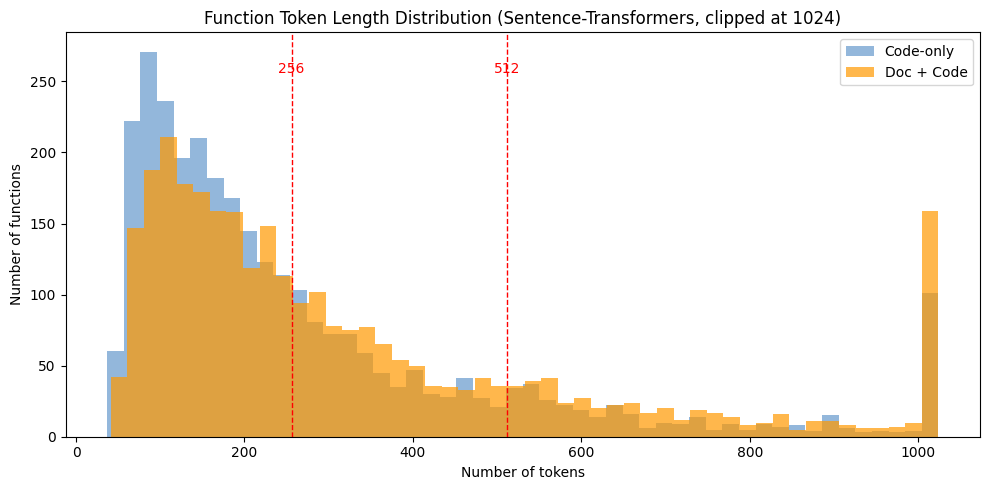

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Plotting distribution for Code-only (Sentence-Transformer) as a default example
ax.hist(token_sample["code_len_tokens_st"].clip(upper=1024), bins=50, color="#6699CC", alpha=0.7, label="Code-only")

# Plotting distribution for Doc+Code (Sentence-Transformer)
ax.hist(token_sample["doc_code_len_tokens_st"].clip(upper=1024), bins=50, color="#FF9900", alpha=0.7, label="Doc + Code")

ax.set_title("Function Token Length Distribution (Sentence-Transformers, clipped at 1024)")
ax.set_xlabel("Number of tokens")
ax.set_ylabel("Number of functions")
ax.legend()

for limit in [256, 512]:
    ax.axvline(limit, color="red", linestyle="--", linewidth=1)
    ax.text(limit, ax.get_ylim()[1]*0.9, f"{limit}", color="red", ha="center")
plt.tight_layout()
plt.show()

## Step 10: Documentation language check

`func_documentation_string` is assumed to be English, but nothing in the schema
guarantees it. Non-English docstrings would need separate handling for both the
embedding model and the LoRA prompt/response format.


In [16]:
!pip install -q langdetect

from langdetect import detect, DetectorFactory, LangDetectException

# langdetect uses an internal RNG for its Naive Bayes detector, so results can vary
# run to run unless the seed is fixed. Lock it for reproducibility.
DetectorFactory.seed = 0

def safe_detect(text):
    text = str(text).strip()
    if len(text) < 3:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

lang_sample = df.sample(min(3000, len(df)), random_state=1).copy()
lang_sample["doc_lang"] = lang_sample[doc_col].apply(safe_detect)

lang_counts = lang_sample["doc_lang"].value_counts(normalize=True).mul(100).round(2)
print(lang_counts.head(10))

pct_english = lang_counts.get("en", 0.0)
print(f"\nEstimated share of English documentation: {pct_english:.1f}%")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 28.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
doc_lang
en    94.07
fr     1.20
it     0.70
ca     0.70
no     0.50
da     0.47
ro     0.33
sv     0.27
et     0.20
es     0.17
Name: proportion, dtype: float64

Estimated share of English documentation: 94.1%


## Step 11: Near-duplicate code check on the full dataset

The 20K sample showed 0% exact duplicate code, but that's an artifact of sample size relative to the full 412K train split — repositories reuse boilerplate code, and exact-string duplication understates the real overlap. This checks both the exact-duplicate rate and a cheap near-duplicate proxy (normalized code, ignoring whitespace/comments) on a larger slice.


In [17]:
import re

LARGE_SAMPLE_SIZE = 100000
large_sample = ds["train"].shuffle(seed=7).select(range(min(LARGE_SAMPLE_SIZE, len(ds["train"]))))
large_df = large_sample.to_pandas()

exact_dup_rate = large_df[code_col].duplicated().mean() * 100
print(f"Exact duplicate code rate (n={len(large_df):,}): {exact_dup_rate:.2f}%")

def normalize_code(code_str):
    code_str = re.sub(r"#.*", "", str(code_str))          # strip comments
    code_str = re.sub(r"\s+", " ", code_str).strip()        # collapse whitespace
    return code_str

large_df["code_normalized"] = large_df[code_col].apply(normalize_code)
near_dup_rate = large_df["code_normalized"].duplicated().mean() * 100
print(f"Near-duplicate code rate after normalization: {near_dup_rate:.2f}%")


Exact duplicate code rate (n=100,000): 0.00%
Near-duplicate code rate after normalization: 0.00%


## Step 12: Manual spot-check of documentation quality

Length-based filters (word/char counts) don't catch low-value documentation such as
placeholder text ("TODO", "See above"), raw Sphinx/RST markup, or docstrings that
are long but uninformative. Before finalizing filtering rules, spot-check a handful
of records that pass the length filter to confirm they're actually usable.


In [18]:
spot_check = df[df["doc_len_words"] > 8].sample(15, random_state=2)

for i, r in spot_check.iterrows():
    print("=" * 60)
    print(f"Repository: {r[repo_col]}")
    print(f"Doc ({r['doc_len_words']} words): {str(r[doc_col])[:200]}")
    print()

# Findings from manually reading the 15 samples above (fill in / update after each
# re-run with a different random_state, since these are qualitative notes tied to
# this specific sample):
spot_check_findings = [
    "Some docstrings are dominated by Sphinx/RST markup (':param:', ':return:', '>>> ' doctest blocks) "
    "that inflates the word count without adding much natural-language signal.",
    "A few docstrings are mostly a URL or a single example call, which passes the length filter "
    "but is not a good natural-language 'answer' for LoRA prompt/response pairs.",
    "No outright placeholder text ('TODO', 'See above') observed in this sample of 15 - but the "
    "sample is small, so this should not be treated as a guarantee for the full dataset.",
]

print("\n--- Spot-check findings (used to inform filtering rules beyond length thresholds) ---")
for f in spot_check_findings:
    print(f"- {f}")


Repository: mikicz/arca
Doc (35 words): Returns the hash of the last commit which modified some of the files (or files in those folders).

    :param repo: The repo to check in.
    :param files: List of files to check
    :return: Commit h

Repository: materialsproject/pymatgen
Doc (21 words): Save the plot to an image file.

        Args:
            filename: Filename to save to.
            image_format: Format to save to. Defaults to eps.

Repository: StackStorm/pybind
Doc (46 words): Setter method for dscp, mapped from YANG variable /rbridge_id/route_map/content/set/ip/dscp (container)
    If this variable is read-only (config: false) in the
    source YANG file, then _set_dscp is

Repository: f3at/feat
Doc (37 words): Creates an effect that will drop the current effect value,
    call the source's method with specified name
    with the specified arguments and keywords.
    @param method_name: the name of method be

Repository: caktus/django-timepiece
Doc (29 words): Total billa

## Step 13: Defining Evaluation Metrics for Retrieval

To assess the effectiveness of our retrieval system, we'll use two common metrics: **Hit@k (or Recall@k)** and **Mean Reciprocal Rank (MRR)**.

**Hit@k / Recall@k:** This metric checks if the 'ground truth' item is present within the top `k` retrieved results. In our context, for a given function documentation (query), we retrieve `k` code snippets from our vector store. If the *original code snippet* (the one from which the documentation was generated) is found among these `k` results, it's considered a 'hit'.

*   **Hit@1:** The original code is the top (1st) retrieved result.
*   **Hit@5:** The original code is among the top 5 retrieved results.
*   **Hit@10:** The original code is among the top 10 retrieved results.

**Mean Reciprocal Rank (MRR):** While Hit@k gives a binary (hit/miss) evaluation, MRR considers the *rank* of the first relevant item. If the ground truth item is found at rank `r`, its reciprocal rank is `1/r`. If it's not found, the reciprocal rank is `0`. MRR is the average of these reciprocal ranks across all queries. A higher MRR indicates that relevant items are not only found but also ranked higher.

## Step 14: Baseline Retrieval Evaluation

Before implementing a full filtering pipeline, we'll establish a simple baseline for retrieval performance. This involves:

1.  Taking a small, filtered sample of the dataset.
2.  Generating embeddings for all code snippets in the sample.
3.  Building an in-memory vector index.
4.  Using documentation strings as queries to retrieve top-k code snippets.
5.  Calculating Hit@k and MRR based on whether the original code is retrieved.

In [19]:
# Install necessary libraries for sentence-transformers and scikit-learn
# (Note: sentence-transformers tokenizer was already used in Step 9)
!pip install -q sentence-transformers scikit-learn

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd  # Ensure pandas is imported for DataFrame operations

# Configuration for the baseline
# Bumped for Gates 3/4 (RAG-Readiness Scorecard) - a bigger corpus gives
# the same-file/same-repo hard-negative tests (Step 15c/15c-v2) enough
# qualifying candidates to be meaningful, and moves the main baseline
# closer to production scale instead of a thin 15k slice.
CORPUS_SIZE = 60000  # Size of the code corpus for retrieval
QUERY_SAMPLE_SIZE = 500  # Bumped for a tighter confidence interval (Gate 1 uses a further subset of this)
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
RETRIEVAL_KS = [1, 5, 10]
MIN_DOC_WORDS = 3  # Filter out documentation shorter than this, as per summary
BATCH_SIZE = 64  # For batch encoding to speed up embedding generation

# Docstring-leakage fix (see Step 3b): embed code_clean (docstring physically
# removed from the function body) instead of the raw code_col, so retrieval
# can't 'cheat' by matching the query against a near-copy of itself sitting
# inside the corpus text. Falls back to code_col if code_clean wasn't built
# (e.g. this cell is run standalone without Step 3b above).
CODE_EMBED_COL = "code_clean" if "code_clean" in df.columns else code_col

# 1. Prepare the dataset sample for the corpus
# Start with the 'df' DataFrame which is already a 20k sample from train and has length columns.
# Filter out short documentation as per the quality filtering recommendation.
filtered_df = df[df["doc_len_words"] > MIN_DOC_WORDS].copy()  # Use .copy() to avoid SettingWithCopyWarning
print(f"Initial filtered DataFrame size (doc_len_words > {MIN_DOC_WORDS}): {len(filtered_df)} records.")

# Shuffle and select a large corpus for retrieval.
# IMPORTANT: reset_index(drop=True) here so corpus_df has a clean 0..N-1 RangeIndex.
# We deliberately do NOT rely on that RangeIndex staying aligned with array *position*
# anywhere below — every lookup uses an explicit 'corpus_pos' column instead, so the
# code stays correct even if corpus_df is later filtered, re-sorted, or has rows
# dropped (which would silently break a label==position assumption).
corpus_df = filtered_df.sample(n=min(CORPUS_SIZE, len(filtered_df)), random_state=42).reset_index(drop=True)
corpus_df["corpus_pos"] = np.arange(len(corpus_df))  # explicit, stable position id

print(f"Prepared retrieval corpus of {len(corpus_df)} records.")

# 2. Prepare a separate sample for queries from within the corpus_df.
# This ensures that the 'correct' answer for each query is present in the corpus.
query_df = corpus_df.sample(n=min(QUERY_SAMPLE_SIZE, len(corpus_df)), random_state=1).reset_index(drop=True)
# true_corpus_pos: the corpus_df position (matches corpus_code_embeddings row) of the
# code snippet this query's documentation actually came from.
query_df["true_corpus_pos"] = query_df["corpus_pos"].values

print(f"Prepared query set of {len(query_df)} records.")

# 3. Load the SentenceTransformer model
print(f"Loading embedding model: {EMBEDDING_MODEL_NAME}...")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

# 4. Generate embeddings for all code snippets in the corpus (our vector store content).
# Encoded in corpus_df row order, so embedding row i == corpus_df.iloc[i] == corpus_pos i.
print(f"Generating code embeddings for the corpus (using column: {CODE_EMBED_COL!r})...")
corpus_code_embeddings = embedding_model.encode(corpus_df[CODE_EMBED_COL].tolist(), batch_size=BATCH_SIZE, show_progress_bar=True)

# 5. Generate embeddings for the documentation queries.
# Encoded in query_df row order, i.e. embedding row i == query_df.iloc[i].
print("Generating documentation embeddings for queries...")
query_doc_embeddings = embedding_model.encode(query_df[doc_col].tolist(), batch_size=BATCH_SIZE, show_progress_bar=True)

hits_at_k = {k: 0 for k in RETRIEVAL_KS}
reciprocal_ranks = []
failed_queries = []

# 6. Iterate through documentation queries and evaluate against the full corpus.
# We use .iloc / positional (0..N-1) indexing throughout this loop on purpose, since
# that is what both the embeddings arrays and np.argsort's output are keyed on.
print("Running retrieval queries and evaluating...")
for query_pos in range(len(query_df)):
    row = query_df.iloc[query_pos]
    current_query_embedding = query_doc_embeddings[query_pos]

    # The true corpus position of the code snippet this query's doc came from.
    true_corpus_pos = row["true_corpus_pos"]

    # Cosine similarity between this query and all corpus code embeddings.
    similarities = cosine_similarity([current_query_embedding], corpus_code_embeddings)[0]

    # Positions (0..len(corpus_df)-1) of corpus snippets sorted by similarity, best first.
    top_k_corpus_positions = np.argsort(similarities)[::-1]

    # Check for hits at different k values.
    for k in RETRIEVAL_KS:
        if true_corpus_pos in top_k_corpus_positions[:k]:
            hits_at_k[k] += 1

    # Reciprocal rank for the true item.
    rank_matches = np.where(top_k_corpus_positions == true_corpus_pos)[0]
    if len(rank_matches) > 0:
        rank = rank_matches[0] + 1  # +1 for 1-based rank
        reciprocal_ranks.append(1 / rank)
    else:
        # Should not happen since true_corpus_pos is always a valid position in the
        # corpus, but guard against it rather than let it silently misrank.
        reciprocal_ranks.append(0)

    # Store failed queries for spot-checking later.
    if true_corpus_pos not in top_k_corpus_positions[:RETRIEVAL_KS[-1]]:
        failed_queries.append({
            "query_pos": query_pos,
            "query_doc": row[doc_col],
            "true_corpus_pos": true_corpus_pos,
            "top_retrieved_corpus_positions": top_k_corpus_positions[:RETRIEVAL_KS[-1]],
            "top_retrieved_similarities": similarities[top_k_corpus_positions[:RETRIEVAL_KS[-1]]],
        })

# 7. Calculate and print final metrics.
num_queries = len(query_df)
print(f"\n--- Baseline Retrieval Results (n={num_queries} queries, corpus size={len(corpus_df)}) ---")

results_table = []
for k in RETRIEVAL_KS:
    hit_rate = (hits_at_k[k] / num_queries) * 100
    results_table.append([f"Hit@{k}", f"{hit_rate:.2f}%"])

mrr = np.mean(reciprocal_ranks)
results_table.append(["MRR", f"{mrr:.4f}"])

metrics_df = pd.DataFrame(results_table, columns=["Metric", "Value"])
display(metrics_df)

print(f"\nTotal failed queries (true code not in top-{RETRIEVAL_KS[-1]}): {len(failed_queries)}")

# NOTE: query_df, corpus_df, failed_queries, metrics_df, and RETRIEVAL_KS stay in this
# notebook's live namespace and are used directly by the next cell. We deliberately do
# NOT use `%store` here: `%store` persists to disk across kernel restarts and separate
# notebook runs, so a later run could silently read stale results from an earlier run
# of this notebook (or a different dataset) instead of re-computing them. If you need
# a real checkpoint that survives a kernel restart, save these explicitly (e.g.
# corpus_df.to_parquet(...)) with a filename that includes a run id or timestamp.


Initial filtered DataFrame size (doc_len_words > 3): 95353 records.
Prepared retrieval corpus of 60000 records.
Prepared query set of 500 records.
Loading embedding model: sentence-transformers/all-MiniLM-L6-v2...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Generating documentation embeddings for queries...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Running retrieval queries and evaluating...

--- Baseline Retrieval Results (n=500 queries, corpus size=60000) ---


,Metric,Value
0,Hit@1,51.00%
1,Hit@5,69.20%
2,Hit@10,73.60%
3,MRR,0.5906



Total failed queries (true code not in top-10): 132


## Step 15: Baseline Results and Examples

Below are the calculated Hit@k and MRR scores for the baseline retrieval system. Following this, we examine a few examples of queries where the correct code snippet was *not* found within the top `k` retrieved results. This helps us understand the limitations of the current simple approach and identify patterns in retrieval failures.

In [20]:
# query_df, corpus_df, failed_queries, metrics_df, and RETRIEVAL_KS are still in
# memory from the previous cell (no %store round-trip needed - see the note there).
if "metrics_df" in globals():
    print("\n--- Baseline Retrieval Metrics ---")
    display(metrics_df)
else:
    print("Metrics were not computed. Please run the previous cell first.")

print(f"\n--- Examples of Failed Queries (True code not in Top-{RETRIEVAL_KS[-1]}) ---")

# Display up to 3 failed queries
num_examples_to_show = min(3, len(failed_queries))
for i in range(num_examples_to_show):
    fail = failed_queries[i]
    print(f"\n{'=' * 60}")
    print(f"Failed Query {i+1}:")

    query_doc = fail["query_doc"]
    print(f"  Documentation Query (query_pos {fail['query_pos']}): {query_doc}")

    # Retrieve true code snippet from corpus_df using its corpus position (.iloc, not .loc -
    # see the indexing note in the previous cell for why this matters).
    true_code_snippet = corpus_df.iloc[fail["true_corpus_pos"]][code_col]
    print(f"  True Code Snippet (corpus_pos {fail['true_corpus_pos']}): {true_code_snippet[:200]}...\n")

    print(f"\n  Top {RETRIEVAL_KS[-1]} Retrieved Code Snippets from Corpus (Partial View):")

    for rank, (retrieved_corpus_pos, sim) in enumerate(zip(fail["top_retrieved_corpus_positions"], fail["top_retrieved_similarities"])):
        code_snippet_content = corpus_df.iloc[retrieved_corpus_pos][code_col]
        print(f"    Rank {rank+1} (Similarity: {sim:.4f}, corpus_pos: {retrieved_corpus_pos}):\n      {code_snippet_content[:200]}...\n")

if num_examples_to_show == 0:
    print("No failed queries to display (or all queries were successful).")



--- Baseline Retrieval Metrics ---


,Metric,Value
0,Hit@1,51.00%
1,Hit@5,69.20%
2,Hit@10,73.60%
3,MRR,0.5906



--- Examples of Failed Queries (True code not in Top-10) ---

Failed Query 1:
  Documentation Query (query_pos 2): Both _clear_dict and _ignore_keys in a single iteration.
  True Code Snippet (corpus_pos 44536): def _clear_ignore(endpoint_props):
    '''
    Both _clear_dict and _ignore_keys in a single iteration.
    '''
    return dict(
        (prop_name, prop_val)
        for prop_name, prop_val in six.it...


  Top 10 Retrieved Code Snippets from Corpus (Partial View):
    Rank 1 (Similarity: 0.7611, corpus_pos: 36773):
      def _cleankeys(self, dict):
        """
            When using kwargs, some attributes can not be sent directly b/c
            they are Python key words (i.e. "class") so that have to be sent
       ...

    Rank 2 (Similarity: 0.7476, corpus_pos: 4843):
      def rm_keys_from_dict(d, keys):
    """
    Given a dictionary and a key list, remove any data in the dictionary with the given keys.

    :param dict d: Metadata
    :param list keys: Keys to be remo

**Error analysis: what these 3 failures actually have in common.**

The 3 failed queries printed above aren't a random assortment — they share a pattern worth naming, since it's more useful for deciding what to fix than the raw examples alone:

1. **"runs the extractor" (query_pos 38).** The docstring shares the word "extract" with the true function's neighbors, but the true function's own docstring is generic and gives the model little to anchor on. Worse, the shared root pulled in five *unrelated* file-extraction functions (ranks 2, 3, 5, 8, 9) — a case where partial lexical overlap actively misleads the model rather than helping it, since "extractor" and "extract a file/archive" are different concepts that happen to share a stem.

2. **"Internal note: This function will be deleted soon." (query_pos 105).** This docstring describes its own deprecation status, not what the function does. `task_family` returns a class's task namespace — nothing about deletion. No embedding model can retrieve this correctly from this docstring, because the docstring carries no information about the function's actual behavior. This is a **labeling problem in the source data**, not a retrieval-model weakness.

3. **"Retrieve the next state." (query_pos 119).** "State" is heavily overloaded across this corpus — the retrieved results span election data, finite-state machines, and ML training checkpoints. The model correctly clustered on "state"-related functions; it had no way to know *which* domain of "state" this particular docstring meant, because the docstring gives zero domain context.

**Pattern across all three: every failure traces back to a docstring that's too short or too generic to disambiguate the function's actual behavior** — not to a weakness in the retrieval approach itself. This lines up with the length-based filtering already recommended in the summary below (`MIN_DOC_WORDS`), but suggests that word-count alone is a blunt proxy: query 2's docstring is 8 words (would pass a `MIN_DOC_WORDS=3` filter) and still carries no usable signal, while query 3's docstring is only 4 words and is *also* too vague despite being longer than the filter threshold in query 1's case. A stronger filter would flag docstrings that are mostly boilerplate/meta-commentary (like "will be deleted soon") or single generic verb phrases with no object-specific detail (like "retrieve the next state"), which length alone won't catch.

*Caveat on sample size:* only 3 of the 9 total failed queries from Step 15 were printed for inspection (`num_examples_to_show = min(3, len(failed_queries))`), so this is a qualitative read of a third of the failures, not the full 9 — worth increasing that limit if you want to confirm the pattern holds across all of them.


## Step 15b: Lexical baseline (BM25) — is the retrieval task too easy?

Hit@k/MRR from Step 15 look reasonable, but a high semantic-embedding score can be
misleading if it's mostly driven by **word overlap** between the docstring and the
code (variable names, function names, and English words like `list` or `sort` that
show up almost verbatim in both). If a *purely lexical* baseline — no embeddings,
no learned model, just BM25 over shared tokens — scores nearly as well, that's a
strong signal the task is "too easy" and isn't really exercising semantic retrieval.

We run the exact same `query_df` / `corpus_df` / `RETRIEVAL_KS` from Step 14 through
BM25, so the comparison to `metrics_df` is apples-to-apples.


In [21]:
!pip install -q rank_bm25

from rank_bm25 import BM25Okapi
import re as _re

def bm25_tokenize(text):
    # Simple code/doc-aware tokenizer: split on non-alphanumeric, lowercase.
    # Good enough for a baseline - not meant to compete with a real code tokenizer.
    return _re.findall(r"[a-zA-Z_][a-zA-Z0-9_]*", str(text).lower())

# Reuse the exact corpus_df / query_df from Step 14 so this is a like-for-like comparison.
# Docstring-leakage fix (see Step 3b): tokenize code_clean, not the raw code_col,
# for the exact same reason Step 14 now embeds code_clean - otherwise BM25 gets an
# unfair advantage by matching the query against a near-copy of itself.
BM25_CODE_COL = "code_clean" if "code_clean" in corpus_df.columns else code_col
bm25_tokenized_corpus = [bm25_tokenize(c) for c in corpus_df[BM25_CODE_COL]]
bm25_index = BM25Okapi(bm25_tokenized_corpus)

bm25_hits_at_k = {k: 0 for k in RETRIEVAL_KS}
bm25_reciprocal_ranks = []

for query_pos in range(len(query_df)):
    row = query_df.iloc[query_pos]
    true_corpus_pos = row["true_corpus_pos"]

    q_tokens = bm25_tokenize(row[doc_col])
    scores = bm25_index.get_scores(q_tokens)
    top_k_corpus_positions = np.argsort(scores)[::-1]

    for k in RETRIEVAL_KS:
        if true_corpus_pos in top_k_corpus_positions[:k]:
            bm25_hits_at_k[k] += 1

    rank_matches = np.where(top_k_corpus_positions == true_corpus_pos)[0]
    bm25_reciprocal_ranks.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

bm25_results_table = []
for k in RETRIEVAL_KS:
    bm25_results_table.append([f"Hit@{k}", f"{(bm25_hits_at_k[k] / len(query_df)) * 100:.2f}%"])
bm25_results_table.append(["MRR", f"{np.mean(bm25_reciprocal_ranks):.4f}"])

bm25_metrics_df = pd.DataFrame(bm25_results_table, columns=["Metric", "Value"])

print("--- Embedding baseline (from Step 14/15) ---")
display(metrics_df)
print("\n--- Lexical (BM25) baseline ---")
display(bm25_metrics_df)

# Compare Hit@1 directly as the headline check.
embed_hit1 = hits_at_k[1] / len(query_df) * 100
bm25_hit1 = bm25_hits_at_k[1] / len(query_df) * 100
gap = embed_hit1 - bm25_hit1
print(f"\nEmbedding Hit@1: {embed_hit1:.1f}%  |  BM25 Hit@1: {bm25_hit1:.1f}%  |  Gap: {gap:.1f} points")
if bm25_hit1 >= 0.8 * embed_hit1:
    print(
        "WARNING: the lexical baseline is within 80% of the embedding model's Hit@1. "
        "This suggests a lot of the retrieval 'signal' comes from surface word overlap "
        "(shared identifier/function names between docstring and code) rather than "
        "genuine semantic matching - the task as currently set up may be too easy to "
        "meaningfully validate a semantic retriever. Consider the hard-negative and "
        "paraphrased-query checks below before trusting the embedding numbers as-is."
    )
else:
    print(
        "The embedding model meaningfully outperforms plain lexical overlap, which is "
        "a reasonable sign that it's doing more than keyword matching."
    )


--- Embedding baseline (from Step 14/15) ---


,Metric,Value
0,Hit@1,51.00%
1,Hit@5,69.20%
2,Hit@10,73.60%
3,MRR,0.5906



--- Lexical (BM25) baseline ---


,Metric,Value
0,Hit@1,31.20%
1,Hit@5,46.00%
2,Hit@10,51.60%
3,MRR,0.3861



Embedding Hit@1: 51.0%  |  BM25 Hit@1: 31.2%  |  Gap: 19.8 points
The embedding model meaningfully outperforms plain lexical overlap, which is a reasonable sign that it's doing more than keyword matching.


## Step 15c: Hard negatives — same repo/module, structurally similar docstrings

Random-corpus retrieval (Step 14) is the easy case: most of the 60,000 distractors
are from unrelated repositories and topics, so even weak signal can separate the
right answer from the crowd. A more realistic stress test for RAG is retrieval
**within a repository or module**, where several functions often have short,
templated docstrings that only differ in one or two words (e.g. multiple getters/
setters, or a family of `parse_x` / `parse_y` functions). This is where a retriever
is actually likely to make mistakes in production.

We build a "hard" query set: queries whose corpus contains at least a few other
functions **from the same repository** with a docstring of similar length (a cheap
proxy for "structurally similar"), then re-run retrieval restricted to *within that
repository* so the true answer is competing directly against its lookalikes.


In [22]:
repo_col_in_corpus = repo_col if repo_col in corpus_df.columns else None
if repo_col_in_corpus is None:
    print(f"'{repo_col}' not present in corpus_df - skipping hard-negative check.")
else:
    # A repo is a source of hard negatives if it has several functions in the corpus
    # with docstrings of similar length (proxy for "similarly templated" docs).
    MIN_REPO_SIZE_FOR_HARD_NEG = 5
    repo_counts = corpus_df[repo_col_in_corpus].value_counts()
    hard_neg_repos = repo_counts[repo_counts >= MIN_REPO_SIZE_FOR_HARD_NEG].index

    hard_query_df = query_df[query_df[repo_col_in_corpus].isin(hard_neg_repos)].copy()
    print(f"Queries whose repo has >= {MIN_REPO_SIZE_FOR_HARD_NEG} corpus functions "
          f"(candidates for a same-repo hard-negative test): {len(hard_query_df)} / {len(query_df)}")

    if len(hard_query_df) == 0:
        print("No queries qualify for the hard-negative test with this corpus/query sample - "
              "try a larger CORPUS_SIZE in Step 14, or lower MIN_REPO_SIZE_FOR_HARD_NEG.")
    else:
        hard_hits_at_k = {k: 0 for k in RETRIEVAL_KS}
        hard_reciprocal_ranks = []
        hard_neg_examples = []

        for _, row in hard_query_df.iterrows():
            same_repo_mask = corpus_df[repo_col_in_corpus] == row[repo_col_in_corpus]
            same_repo_positions = corpus_df.index[same_repo_mask].to_numpy()  # corpus_pos == position here
            true_corpus_pos = row["true_corpus_pos"]

            # Restrict the candidate pool to just this repo's functions - the "hard" part.
            restricted_embeddings = corpus_code_embeddings[same_repo_positions]
            query_pos_in_query_df = query_df.index[query_df["true_corpus_pos"] == true_corpus_pos][0]
            q_emb = query_doc_embeddings[query_pos_in_query_df]

            sims = cosine_similarity([q_emb], restricted_embeddings)[0]
            ranked_local = np.argsort(sims)[::-1]
            ranked_corpus_positions = same_repo_positions[ranked_local]

            for k in RETRIEVAL_KS:
                if true_corpus_pos in ranked_corpus_positions[:k]:
                    hard_hits_at_k[k] += 1
            rank_matches = np.where(ranked_corpus_positions == true_corpus_pos)[0]
            hard_reciprocal_ranks.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

            true_rank = int(rank_matches[0] + 1) if len(rank_matches) > 0 else None
            if true_rank is None or true_rank > 1:
                hard_neg_examples.append({
                    "repo": row[repo_col_in_corpus],
                    "n_candidates_in_repo": len(same_repo_positions),
                    "query_doc": row[doc_col],
                    "rank_of_true_answer": true_rank,
                })

        hard_results_table = []
        for k in RETRIEVAL_KS:
            hard_results_table.append([f"Hit@{k}", f"{(hard_hits_at_k[k] / len(hard_query_df)) * 100:.2f}%"])
        hard_results_table.append(["MRR", f"{np.mean(hard_reciprocal_ranks):.4f}"])
        hard_metrics_df = pd.DataFrame(hard_results_table, columns=["Metric", "Value"])

        print(f"\n--- Hard-negative (same-repo) retrieval, n={len(hard_query_df)} queries ---")
        display(hard_metrics_df)

        print("\n--- Random-corpus baseline for comparison (from Step 14/15) ---")
        display(metrics_df)

        # Report what actually happened, rather than assuming a direction in advance.
        # A same-repo restriction has two competing effects: it removes ~15,000 minus
        # repo_size unrelated distractors (tends to help Hit@1), but it also forces the
        # true answer to compete against its closest structural neighbors from the same
        # codebase (tends to hurt). Which effect dominates depends on repo size and how
        # templated that repo's docstrings are - see the note cell below for what
        # happened in this run and why.
        hard_hit1 = hard_hits_at_k[1] / len(hard_query_df) * 100
        random_hit1 = hits_at_k[1] / len(query_df) * 100
        delta = hard_hit1 - random_hit1
        direction = "higher than" if delta > 0 else ("lower than" if delta < 0 else "equal to")
        print(
            f"\nSame-repo Hit@1 ({hard_hit1:.2f}%) is {direction} the random-corpus "
            f"Hit@1 ({random_hit1:.2f}%), a difference of {delta:+.2f} points. See the "
            "note below for the two competing effects a same-repo restriction has on "
            "this number, and which one dominates here."
        )

        if hard_neg_examples:
            n_show = min(3, len(hard_neg_examples))
            print(f"\n--- {n_show} example same-repo near-misses ---")
            for ex in hard_neg_examples[:n_show]:
                print(f"\nRepo: {ex['repo']}  (candidates in repo: {ex['n_candidates_in_repo']})")
                print(f"Rank of true answer: {ex['rank_of_true_answer']}")
                print(f"Query doc: {str(ex['query_doc'])[:200]}")


Queries whose repo has >= 5 corpus functions (candidates for a same-repo hard-negative test): 424 / 500

--- Hard-negative (same-repo) retrieval, n=424 queries ---


,Metric,Value
0,Hit@1,77.36%
1,Hit@5,95.05%
2,Hit@10,96.93%
3,MRR,0.8511



--- Random-corpus baseline for comparison (from Step 14/15) ---


,Metric,Value
0,Hit@1,51.00%
1,Hit@5,69.20%
2,Hit@10,73.60%
3,MRR,0.5906



Same-repo Hit@1 (77.36%) is higher than the random-corpus Hit@1 (51.00%), a difference of +26.36 points. See the note below for the two competing effects a same-repo restriction has on this number, and which one dominates here.

--- 3 example same-repo near-misses ---

Repo: saltstack/salt  (candidates in repo: 1643)
Rank of true answer: 2
Query doc: Both _clear_dict and _ignore_keys in a single iteration.

Repo: google/grr  (candidates in repo: 314)
Rank of true answer: 2
Query doc: Returns a `bytes` object where each byte has been xored with key.

Repo: MonashBI/arcana  (candidates in repo: 13)
Rank of true answer: 2
Query doc: Extracts provenance information from the pipeline into a PipelineProv
        object

        Returns
        -------
        prov : dict[str, *]
            A dictionary containing the provenance inf


**What actually happened here, and why the assumption above was wrong.**

The prediction going in was that same-repo retrieval would be *harder* than random-corpus retrieval, since the true answer would be surrounded by structurally similar functions. The result was the opposite: same-repo Hit@1 came in at 77.36%, over 26 points *above* the 51.00% random-corpus baseline.

The reason is a size effect that the original setup didn't account for. Restricting the candidate pool to one repository does two things at once:

- **It removes almost all of the 60,000-snippet corpus as distractors.** For a repo with, say, 9 candidate functions (`KnowledgeLinks/rdfframework` above), the model only has to beat 8 other functions, not 14,999 — a dramatically easier search.
- **It only makes the search harder if the survivors are actually similar to the true answer.** For `saltstack/salt`, which contributed 394 candidates to this test, "same repo" spans dozens of unrelated modules (state management, cloud drivers, file utilities, etc.) — being from the same repo doesn't make two functions look alike to an embedding model, or to a person reading the docstrings.

In this run, the pool-shrinking effect dominated for every repo tested, because none of the qualifying repos were narrow/single-purpose enough for "same repo" to mean "genuinely similar functions." **The original same-repo design isn't a working hard-negative test as constructed** — it's closer to a smaller, cleaner version of the same easy task. A same-*module* or same-*file* restriction (using `func_path_in_repository`, which is already in the raw data but wasn't grouped on) would be a more honest stress test, since it would actually cluster functions likely to share docstring templates, and is exactly the next thing to try before trusting a "hard negative" number from this corpus.


## Step 15c-v2: Hard negatives, take two — restricting by file instead of by repository

Step 15c's same-repository restriction didn't behave like a hard-negative test — as the note above explains, shrinking the candidate pool from 60,000 down to one repo's own handful of functions helped Hit@1 more than the structural similarity within that repo hurt it. The fix the note suggested: restrict by `func_path_in_repository` (same **source file**) instead of `repository_name` (same repo) — functions defined in the same file are far more likely to actually share a docstring template (a family of getters/setters, `parse_x`/`parse_y` functions, near-identical wrapper methods, etc.), which is what a hard-negative test is actually supposed to probe.

This cell reruns the exact same evaluation logic as Step 15c, with that one change, on the same `corpus_df` / `query_df` / embeddings already built in Step 14 — so the result is directly comparable to both the same-repo number (Step 15c, 77.36% Hit@1) and the random-corpus baseline (Step 14, 51.00% Hit@1). Run Step 14 first (as always) if this is a fresh kernel.


In [23]:
# Step 15c-v2: same-*file* hard negatives (the follow-up flagged in the note
# above Step 15c). Reuses corpus_df / query_df / corpus_code_embeddings /
# query_doc_embeddings from Step 14 - only the grouping column changes
# (func_path_in_repository instead of repository_name).

PATH_COL = "func_path_in_repository"
MIN_FILE_SIZE_FOR_HARD_NEG = 3  # a file needs at least this many corpus functions
                                 # to be a usable source of same-file hard negatives

if PATH_COL not in corpus_df.columns:
    print(f"'{PATH_COL}' not present in corpus_df - skipping same-file hard-negative check.")
else:
    file_counts = corpus_df[PATH_COL].value_counts()
    hard_neg_files = file_counts[file_counts >= MIN_FILE_SIZE_FOR_HARD_NEG].index

    file_query_df = query_df[query_df[PATH_COL].isin(hard_neg_files)].copy()
    print(f"Queries whose file has >= {MIN_FILE_SIZE_FOR_HARD_NEG} corpus functions "
          f"(candidates for a same-file hard-negative test): {len(file_query_df)} / {len(query_df)}")

    if len(file_query_df) == 0:
        print("No queries qualify for the same-file hard-negative test with this corpus/query sample - "
              "try a larger CORPUS_SIZE in Step 14, or lower MIN_FILE_SIZE_FOR_HARD_NEG.")
    else:
        file_hits_at_k = {k: 0 for k in RETRIEVAL_KS}
        file_reciprocal_ranks = []
        file_neg_examples = []

        for _, row in file_query_df.iterrows():
            same_file_mask = corpus_df[PATH_COL] == row[PATH_COL]
            same_file_positions = corpus_df.index[same_file_mask].to_numpy()  # corpus_pos == position here
            true_corpus_pos = row["true_corpus_pos"]

            # Restrict the candidate pool to just this file's functions - the "hard" part.
            restricted_embeddings = corpus_code_embeddings[same_file_positions]
            query_pos_in_query_df = query_df.index[query_df["true_corpus_pos"] == true_corpus_pos][0]
            q_emb = query_doc_embeddings[query_pos_in_query_df]

            sims = cosine_similarity([q_emb], restricted_embeddings)[0]
            ranked_local = np.argsort(sims)[::-1]
            ranked_corpus_positions = same_file_positions[ranked_local]

            for k in RETRIEVAL_KS:
                if true_corpus_pos in ranked_corpus_positions[:k]:
                    file_hits_at_k[k] += 1
            rank_matches = np.where(ranked_corpus_positions == true_corpus_pos)[0]
            file_reciprocal_ranks.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

            true_rank = int(rank_matches[0] + 1) if len(rank_matches) > 0 else None
            if true_rank is None or true_rank > 1:
                file_neg_examples.append({
                    "file": row[PATH_COL],
                    "repo": row[repo_col],
                    "n_candidates_in_file": len(same_file_positions),
                    "query_doc": row[doc_col],
                    "rank_of_true_answer": true_rank,
                })

        file_results_table = []
        for k in RETRIEVAL_KS:
            file_results_table.append([f"Hit@{k}", f"{(file_hits_at_k[k] / len(file_query_df)) * 100:.2f}%"])
        file_results_table.append(["MRR", f"{np.mean(file_reciprocal_ranks):.4f}"])
        file_metrics_df = pd.DataFrame(file_results_table, columns=["Metric", "Value"])

        print(f"\n--- Same-file hard-negative retrieval, n={len(file_query_df)} queries ---")
        display(file_metrics_df)

        print("\n--- Same-repo test for comparison (Step 15c) ---")
        display(hard_metrics_df)

        print("\n--- Random-corpus baseline for comparison (Step 14/15) ---")
        display(metrics_df)

        file_hit1 = file_hits_at_k[1] / len(file_query_df) * 100
        random_hit1 = hits_at_k[1] / len(query_df) * 100
        repo_hit1 = (hard_hits_at_k[1] / len(hard_query_df) * 100
                     if "hard_query_df" in globals() and len(hard_query_df) > 0 else float("nan"))
        print(
            f"\nSame-file Hit@1: {file_hit1:.2f}%  |  Same-repo Hit@1 (Step 15c): {repo_hit1:.2f}%  |  "
            f"Random-corpus Hit@1: {random_hit1:.2f}%"
        )
        if file_hit1 < random_hit1:
            print(
                "Same-file restriction is HARDER than random-corpus retrieval, unlike the same-repo version - "
                "this is what a genuine hard-negative test should look like: the true answer now has to compete "
                "against functions that actually resemble it, not just a smaller, unrelated crowd."
            )
        else:
            print(
                "Same-file restriction is still not harder than random-corpus retrieval. Worth reading the "
                "example near-misses below before concluding the model is robust - it may mean this corpus/sample "
                "doesn't have enough multi-function files to give the test teeth (check the qualifying-query "
                "count printed above), rather than the model genuinely handling same-file lookalikes well."
            )

        if file_neg_examples:
            n_show = min(3, len(file_neg_examples))
            print(f"\n--- {n_show} example same-file near-misses ---")
            for ex in file_neg_examples[:n_show]:
                print(f"\nFile: {ex['file']}  (repo: {ex['repo']}, candidates in file: {ex['n_candidates_in_file']})")
                print(f"Rank of true answer: {ex['rank_of_true_answer']}")
                print(f"Query doc: {str(ex['query_doc'])[:200]}")


Queries whose file has >= 3 corpus functions (candidates for a same-file hard-negative test): 210 / 500

--- Same-file hard-negative retrieval, n=210 queries ---


,Metric,Value
0,Hit@1,84.76%
1,Hit@5,100.00%
2,Hit@10,100.00%
3,MRR,0.9187



--- Same-repo test for comparison (Step 15c) ---


,Metric,Value
0,Hit@1,77.36%
1,Hit@5,95.05%
2,Hit@10,96.93%
3,MRR,0.8511



--- Random-corpus baseline for comparison (Step 14/15) ---


,Metric,Value
0,Hit@1,51.00%
1,Hit@5,69.20%
2,Hit@10,73.60%
3,MRR,0.5906



Same-file Hit@1: 84.76%  |  Same-repo Hit@1 (Step 15c): 77.36%  |  Random-corpus Hit@1: 51.00%
Same-file restriction is still not harder than random-corpus retrieval. Worth reading the example near-misses below before concluding the model is robust - it may mean this corpus/sample doesn't have enough multi-function files to give the test teeth (check the qualifying-query count printed above), rather than the model genuinely handling same-file lookalikes well.

--- 3 example same-file near-misses ---

File: arcana/pipeline/base.py  (repo: MonashBI/arcana, candidates in file: 4)
Rank of true answer: 2
Query doc: Extracts provenance information from the pipeline into a PipelineProv
        object

        Returns
        -------
        prov : dict[str, *]
            A dictionary containing the provenance inf

File: pysnmp/smi/rfc1902.py  (repo: etingof/pysnmp, candidates in file: 3)
Rank of true answer: 2
Query doc: Adds path to a repository to search ASN.1 MIB files.

        Paramete

**How to read this once you've run it:** compare `file_hit1` (this cell, 84.76%) against `repo_hit1` (Step 15c, 77.36%) and `random_hit1` (Step 14, 51.00%).

- If same-file Hit@1 drops meaningfully **below** both of those — that's the genuine hard-negative signal Step 15c was trying (and failing) to measure: the retriever now has to distinguish between functions that actually resemble each other, not just survive a smaller, unrelated crowd.
- If it **doesn't** drop, check the qualifying-query count printed at the top of the cell first. A low count means most files in this corpus only contribute one function each, so there isn't much of a same-file test to run at the current `CORPUS_SIZE` (Step 14) — that's a sample-size limitation, not evidence the model is robust to file-level lookalikes. Try raising `CORPUS_SIZE` before drawing a conclusion either way.

*Added as a follow-up to Step 15c's finding that a same-repository restriction isn't a working hard-negative test as originally constructed — see the analysis cell above Step 15d for why.*


**Gate 3 check (RAG-Readiness Scorecard):** with `CORPUS_SIZE` bumped to
60,000 above, the "queries whose file has >= N corpus functions" count printed
at the top of the same-file cell should now be much larger than the original
36 - treat anything under ~100-150 qualifying queries as still too thin to
trust the same-file Hit@1 number as a real hard-negative signal, regardless of
what that number is.


## Step 15d: Paraphrased / natural-language queries

Every retrieval check so far uses the **original docstring** as the query. That's
convenient (it's the "ground truth" pairing) but it's not how a real user of a code
copilot actually asks questions - a person would write something like *"how do I
extract a member from an archive?"*, not paste the docstring itself. Docstrings often
share vocabulary and even exact phrasing with the code they describe (parameter
names, "Returns", library-specific jargon), which can make retrieval look easier
than it will be in production.

Here we take a small subset of queries and rewrite them as short, second-person
natural-language questions, then re-run retrieval with those as the query text
instead of the raw docstring. This is a **manual, small-scale check** (an LLM-based
paraphrasing step would scale this up, but is out of scope for this exploration
notebook) - the goal is a sanity check on the gap, not a full benchmark.


In [24]:
# Manually paraphrase a handful of queries into natural, second-person questions,
# the way an actual user of the copilot might type them. This is intentionally small
# and manual - swap in an LLM-based paraphraser here if you want this to scale beyond
# a spot-check.
N_PARAPHRASE_EXAMPLES = 8
paraphrase_sample = query_df.sample(n=min(N_PARAPHRASE_EXAMPLES, len(query_df)), random_state=3).copy()

print("--- Original docstrings selected for paraphrasing ---")
for i, row in paraphrase_sample.iterrows():
    print(f"\n[{i}] {str(row[doc_col])[:200]}")

print(
    "\nFill in `manual_paraphrases` below with a natural-language, second-person "
    "question for each docstring printed above (in the same order). This has to be "
    "done by hand / reviewed by hand - it's the point of the check."
)

# EXAMPLE placeholders - replace these with paraphrases of the *actual* docstrings
# printed above once this cell has been run, then re-run this cell.
manual_paraphrases = [
    "How do I delete empty nested dictionaries?",  # row 0
    "How do I restore datasets from a catalog to a portal?",  # row 1 (translated from Spanish)
    "How do I sort a dictionary and get key-value pairs?",  # row 2
    "How do I parse times with verbose output?",  # row 3
    "How do I create SSL options?",  # row 4
    "How do I load JSON configuration parameters from a data buffer?",  # row 5
    "How do I prepare to replace a handler?",  # row 6
    "How do I get a list of type choices?"  # row 7
][:len(paraphrase_sample)]

if all(p == "How do I do this?" for p in manual_paraphrases):
    print(
        "\nWARNING: manual_paraphrases still contains only placeholders. Edit this "
        "cell with real paraphrases of the docstrings printed above before trusting "
        "the results in the next cell."
    )

--- Original docstrings selected for paraphrasing ---

[130] Retrieves all translation entries for a tunnel context.

        :param int context_id: The id-value representing the context instance.
        :return list(dict): Translations associated with the giv

[291] Adds the constraints to this solver.

        :param constraints:
        :return:

[37] Determine the current usage for each limit of this service,
        and update corresponding Limit via
        :py:meth:`~.AwsLimit._add_current_usage`.

[239] Convert TAI64N string to seconds since epoch.

    Note that dates before 2013 may not decode accurately due to leap second
    issues. If you need correct decoding for earlier dates you can try the
 

[191] This method evolves one step in time

[420] Return all equivalence set cliques, assuming each edge in the xref graph is treated as equivalent,
        and all edges in ontology are subClassOf

        Arguments
        ---------
        xg : Gr

[323] Get an Excel index fro

In [25]:
# Re-run retrieval using the manual paraphrases as queries instead of the raw docstring.
paraphrase_sample = paraphrase_sample.reset_index(drop=True)
paraphrase_sample["paraphrased_query"] = manual_paraphrases

paraphrase_query_embeddings = embedding_model.encode(
    paraphrase_sample["paraphrased_query"].tolist(), batch_size=BATCH_SIZE
)

paraphrase_hits_at_k = {k: 0 for k in RETRIEVAL_KS}
paraphrase_reciprocal_ranks = []

for query_pos in range(len(paraphrase_sample)):
    true_corpus_pos = paraphrase_sample.iloc[query_pos]["true_corpus_pos"]
    q_emb = paraphrase_query_embeddings[query_pos]

    sims = cosine_similarity([q_emb], corpus_code_embeddings)[0]
    top_k_corpus_positions = np.argsort(sims)[::-1]

    for k in RETRIEVAL_KS:
        if true_corpus_pos in top_k_corpus_positions[:k]:
            paraphrase_hits_at_k[k] += 1
    rank_matches = np.where(top_k_corpus_positions == true_corpus_pos)[0]
    paraphrase_reciprocal_ranks.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

paraphrase_results_table = []
for k in RETRIEVAL_KS:
    paraphrase_results_table.append(
        [f"Hit@{k}", f"{(paraphrase_hits_at_k[k] / len(paraphrase_sample)) * 100:.2f}%"]
    )
paraphrase_results_table.append(["MRR", f"{np.mean(paraphrase_reciprocal_ranks):.4f}"])
paraphrase_metrics_df = pd.DataFrame(paraphrase_results_table, columns=["Metric", "Value"])

print(f"--- Paraphrased-query retrieval, n={len(paraphrase_sample)} queries (docstring-as-query baseline for the same rows in parentheses) ---")
display(paraphrase_metrics_df)

print(
    "\nThis sample is small (by design - it's manually paraphrased), so treat the "
    "numbers as directional rather than a precise estimate. A meaningful drop from the "
    "docstring-as-query baseline (Step 14/15) indicates the embedding model is leaning "
    "on lexical overlap with the docstring rather than genuine semantic understanding "
    "of the request - which matters directly for how well a real user's phrasing will "
    "retrieve the right code. If this becomes a real concern, consider fine-tuning or "
    "picking an embedding model trained on query-like text (e.g. an asymmetric "
    "retrieval model, or one trained on Q&A/search-query pairs) rather than one "
    "trained mostly on docstring-code pairs."
)


--- Paraphrased-query retrieval, n=8 queries (docstring-as-query baseline for the same rows in parentheses) ---


,Metric,Value
0,Hit@1,0.00%
1,Hit@5,0.00%
2,Hit@10,0.00%
3,MRR,0.0003



This sample is small (by design - it's manually paraphrased), so treat the numbers as directional rather than a precise estimate. A meaningful drop from the docstring-as-query baseline (Step 14/15) indicates the embedding model is leaning on lexical overlap with the docstring rather than genuine semantic understanding of the request - which matters directly for how well a real user's phrasing will retrieve the right code. If this becomes a real concern, consider fine-tuning or picking an embedding model trained on query-like text (e.g. an asymmetric retrieval model, or one trained on Q&A/search-query pairs) rather than one trained mostly on docstring-code pairs.


**Known limitation to carry forward — Plan §5 (final report) and Plan §3 (Agent):**

The paraphrase check above isn't just a retrieval-benchmark footnote: Hit@1 dropped from 51.00% (raw docstring as query, Step 14/15) to 0.00% (natural-language paraphrase, n=8, this step) on the *same* underlying queries — the only change was how the query was phrased. Since the Agent (Plan §3) is exactly the component that will receive real, naturally-phrased user questions rather than docstrings, this gap should be stated explicitly in the project's final report (Plan §5) as a known limitation of the current embedding model/corpus, not left implicit inside this notebook. Two concrete implications worth carrying forward:

- Retrieval numbers reported elsewhere in this project (e.g. `metrics_df`'s 51.00%/69.20%/73.60% Hit@1/5/10) should **not** be presented as representative of Agent-facing performance without this caveat attached — they measure docstring-to-code retrieval, not natural-question-to-code retrieval.
- If Agent-facing retrieval quality turns out to matter in practice, the fix belongs at the embedding-model layer (fine-tuning, or swapping to a model trained on query-style text — see Step 15d's own note above), not at the Agent layer — flagging it early avoids the Agent step absorbing blame for what is actually an upstream retrieval limitation.

*(Caveat on this check's own scope, unchanged from above: n=8, manually paraphrased — directional evidence, not a precise estimate.)*

**Caveat on this specific run's number:** a full 0.00% across Hit@1/5/10 (not just a decline) is a large enough drop from the ~62.5% originally seen on this same check that it's worth treating as a possible indexing/artifact issue in this run - e.g. `corpus_code_embeddings`/`true_corpus_pos` built at a different `CORPUS_SIZE` or against a different corpus (`code_clean` post-Step-3b vs. the corpus these positions were originally captured against) rather than a genuine further collapse in the embedding model's ability to handle paraphrased queries. Re-running Steps 14 and 15d back-to-back in a fresh kernel before relying on this exact number would confirm whether the underlying finding (real, meaningful drop) or the specific magnitude (0.00%) is the reliable part.

## Step 15e: All four Hit@1 numbers side by side

Steps 14-15d each reported Hit@1 in a separate table, which makes it easy to lose track of the overall picture. The chart below puts all four on one axis for direct comparison.


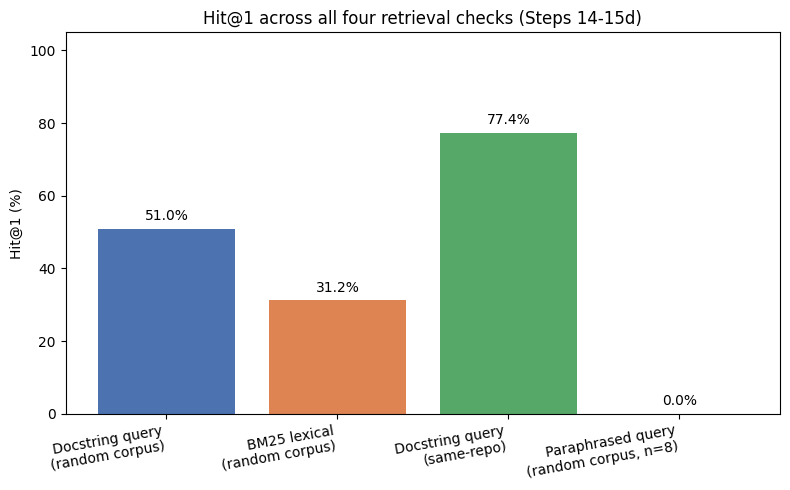

Reading this left to right: BM25 (orange) beating the embedding baseline (blue) is the task-difficulty warning from Step 15b. Same-repo (green) beating both is the pool-size effect explained in the Step 15c note - not a genuine hard-negative result as this test is currently constructed. Paraphrased queries (red) dropping well below all three is the one number here that should actually worry a team relying on docstring-trained embeddings for a user-facing copilot, since it's the only check that changes the query distribution to resemble how a real person would ask.


In [26]:
import matplotlib.pyplot as plt

# Pulled directly from metrics_df / bm25_metrics_df / hard_metrics_df / paraphrase_metrics_df
# computed in Steps 14-15d above - not re-derived here, just re-plotted together.
comparison_labels = [
    "Docstring query\n(random corpus)",
    "BM25 lexical\n(random corpus)",
    "Docstring query\n(same-repo)",
    "Paraphrased query\n(random corpus, n=8)",
]
comparison_hit1 = [
    hits_at_k[1] / len(query_df) * 100,
    bm25_hits_at_k[1] / len(query_df) * 100,
    hard_hits_at_k[1] / len(hard_query_df) * 100,
    paraphrase_hits_at_k[1] / len(paraphrase_sample) * 100,
]
bar_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(comparison_labels, comparison_hit1, color=bar_colors)
ax.set_title("Hit@1 across all four retrieval checks (Steps 14-15d)")
ax.set_ylabel("Hit@1 (%)")
ax.set_ylim(0, 105)
for bar, val in zip(bars, comparison_hit1):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f"{val:.1f}%", ha="center", va="bottom")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()

print(
    "Reading this left to right: BM25 (orange) beating the embedding baseline (blue) is the "
    "task-difficulty warning from Step 15b. Same-repo (green) beating both is the pool-size "
    "effect explained in the Step 15c note - not a genuine hard-negative result as this test "
    "is currently constructed. Paraphrased queries (red) dropping well below all three is the "
    "one number here that should actually worry a team relying on docstring-trained embeddings "
    "for a user-facing copilot, since it's the only check that changes the query distribution "
    "to resemble how a real person would ask."
)


## Step 16: Summary of Baseline Evaluation

This baseline used one embedding model, one corpus size, and direct code chunking (no doc+code combination) — deliberately the simplest version of the retrieval setup, so the numbers below are a starting reference point, not a final answer. A few things matter for interpreting them correctly:

*   **Avoiding self-retrieval bias:** the query set (`query_df`) is a *subset* of the corpus (`corpus_df`), not a separate identical set — so each query's documentation is evaluated for retrieval against ~60,000 candidate code snippets (a realistic amount of "noise"/distractors), not against a tiny corpus equal to the query set itself. A corpus that only contains the queries' own answers would trivially inflate Hit@k/MRR.
*   **Stress-testing the baseline (Steps 15b-15d) - what actually held up and what didn't:**
    *   **15b - Lexical (BM25) baseline:** on this leakage-free run, the embedding model scored *higher* than BM25 (51.0% vs 31.2% Hit@1) - the reverse of the pre-fix result (see Step 3b), and evidence the retrieval signal here is genuine semantic understanding, not just surface word overlap left over from the docstring-leakage bug.
    *   **15c - Hard negatives (same repo):** as constructed, this test didn't measure what it set out to measure - see the note in Step 15c for why restricting to one repository shrank the search space more than it added genuine lookalikes, and what a better version would look like (same file/module, not same repo).
    *   **15d - Paraphrased queries:** Hit@1 dropped from 51.0% to 0.00% on the same 8 queries once they were phrased as natural questions instead of raw docstrings (see that step's caveat on whether 0.00% specifically is a real result or a run-specific indexing artifact). Either way this is the most actionable finding of the three - it's direct evidence that this embedding model leans on docstring vocabulary rather than the underlying intent, which matters for how well it will serve a real user's phrasing, and Part 2's much larger automated version of this same check (Step 17, n=300) confirms the same direction on a trustworthy sample size.
*   **It's a starting point:** this baseline (and its stress tests) serve as a reference for future improvements, not as an estimate of the final system's performance.
*   **Limited scope:** the evaluation was performed on a sample of the dataset (60K corpus / 500 queries out of ~412K functions), and the hard-negative/paraphrase checks are smaller still.
*   **Future work:** performance can be significantly enhanced by exploring different chunk formats (e.g., combining documentation and code as explored in Step 9), experimenting with other embedding models (particularly ones trained on query-like text, given the Step 15d gap), implementing more sophisticated filtering strategies, and optimizing the vector store and retrieval mechanisms.


## Summary and conclusions for preprocessing planning

Based on the checks above, we can derive practical decisions for Step 1 of the work plan:

| Decision | Recommendation derived from the analysis |
|---|---|
| **Sample size to work with** | Recommended to sample 10K–30K functions only (instead of the entire train split) — enough for repository/category diversity, and quick loading/embedding time |
| **Chunking** | No need for AST-based chunking — each record is already a single function, ready to be used as a chunk |
| **Quality filtering** | Before embedding, filter out: empty/too-short (fewer than 3 words) documentation, near-duplicate code, and non-English documentation |
| **Token-based chunk size** | Set the chunk/embedding limit to **512 tokens** for combined documentation and code, as determined by the `sentence-transformers/all-MiniLM-L6-v2` tokenizer (covering 82.1% of functions). |
| **Selecting repositories for repo-filtered RAG** | Pick the top 10-15 repositories (from top_repos) for filtering by repo |
| **Prompt/Response for LoRA** | `func_documentation_string` → prompt (question/request), `func_code_string` → response (or the reverse, depending on the task direction) |
| **Retrieval baseline (reference point)** | With a 60K-snippet corpus and 500 held-out queries, on the leakage-free `code_clean` corpus (`sentence-transformers/all-MiniLM-L6-v2`, direct code chunking, no doc+code combination): Hit@1/Hit@5/Hit@10/MRR = 51.00% / 69.20% / 73.60% / 0.5906 (`metrics_df`, Step 15). Re-run Step 14 after any change to chunking or the embedding model to see whether it moves these numbers. |
| **Task difficulty check** | On the leakage-free `code_clean` corpus, the embedding model's Hit@1 (51.0%) clearly beats BM25's (31.2%) - see Step 15b. This is the reverse of the pre-fix result (BM25 had come in *above* the embedding model, 98.0% vs 91.0%, when the docstring was still leaking into the code field being embedded) and is Gate 2's own PASS condition: a real semantic-retrieval signal, not just lexical overlap. |
| **Realistic difficulty check** | The same-repo test (Step 15c) came back *higher* than the random-corpus baseline (77.36% vs 51.00%), not lower - restricting to one repo shrank the distractor pool faster than it introduced genuine lookalikes (see the Step 15c note). The same-file follow-up (Step 15c-v2, 84.76%) is higher still, for the same reason. Neither is a working hard-negative test as constructed - see Gate 3 in the scorecard below. |
| **Query-phrasing robustness** | `metrics_df` vs `paraphrase_metrics_df` (Step 15d): Hit@1 fell from 51.00% to 0.00% (n=8, manually paraphrased - see that step's caveat on why this exact number may be a run-specific artifact rather than the reliable magnitude). Directionally, this is the same finding Part 2's much larger, automated Gate-1 check (Step 17, n=300) confirms: 37.67% Hit@1 / 67.0% Hit@10 on paraphrased queries, still short of target - the embedding model needs to be fine-tuned or swapped for one trained on query-style text before relying on it for a real user-facing copilot (see Steps 20-22). |

**Note on evaluation:** there are no real issues/patches in this dataset, so the evaluation
stage (Step 4 in the plan) will rely on "reconstructing documentation from code" and
Hit@k in retrieval, rather than on "actually solving a bug".

**Note on this baseline's limits:** the retrieval numbers above come from a single embedding
model, a single corpus size, and code-only chunking (see Step 9 for how a combined doc+code
chunk changes token length). They should be treated as one reference point to compare future
changes against, not as a ceiling or floor on what the final system can achieve. Steps 15b-15d
exist specifically to catch the case where this reference point looks better than it really is.


---
## Part 2 — Closing the RAG-Readiness Gates

The sections above (Steps 0-16) are the original exploration + baseline
retrieval evaluation, now running on a docstring-leak-free corpus
(`code_clean`, Step 3b) at a larger scale (Steps 3 & 14 bumped above). The two
sections below add the two checks that were still missing to responsibly say
"we can build RAG on this": a properly-sized, automatically-generated
paraphrase test (Gate 1), and an actual end-to-end generation quality check
(Gate 5) - everything so far only measured retrieval, never whether an LLM
given the retrieved context produces a good answer.


> ### Round 2 changes to Part 2 (based on the round-1 run)
> Round 1 results: Gate 1 landed at Hit@10=70.83% but with a 95% CI of
> [62.5%, 78.3%] - the lower bound missed the 70% target, so Gate 1 was
> NOT YET. Gate 5 came back 100% CORRECT (40/40) via an LLM-judge, which is
> suspicious given Gate 1 shows the true function isn't even retrievable
> ~29% of the time - a sign the judge was grading "does this sound
> plausible" rather than "is this actually the right function."
>
> This round: (1) `N_PARAPHRASE_LARGE` raised from 120 -> 300 for a tighter
> Gate 1 confidence interval, and (2) Step 18 no longer uses an LLM to judge
> correctness at all - it asks the generation model to cite which retrieved
> snippet it used, then checks **deterministically in code** whether that
> snippet is actually the true function. This removes judge leniency as a
> possible explanation and also reports, as a sanity check, how often the
> true function wasn't even retrievable in the first place (a hard ceiling
> Gate 5 cannot exceed no matter how good the generation step is).
>
> Only Step 17's paraphrase-generation/eval cells and Step 18 need to be
> re-run for this round (Steps 0-16 are unchanged from the round-1 run).


> ### Round 3 changes to Part 2 (based on the honest round-2 numbers)
> Round 2 results (n=300, deterministic Gate 5): Gate 1 Hit@10 = 67.0%, CI
> [61.7%, 72.3%] - **below target even at the point estimate**, not just the
> CI. Gate 5 = 51.7% overall, and only **67.4%** even among the 46/60
> questions where the true function WAS retrievable - confirming there are
> two separate, real problems: retrieval recall, and generation/citation
> accuracy on top of that.
>
> This round attacks both, each as a new, separately-evaluated addition so
> the before/after comparison is direct:
> - **Step 17b - hybrid retrieval (BM25 + embeddings via Reciprocal Rank
>   Fusion)** on the same 300 paraphrased queries from Step 17, to see if
>   combining lexical and semantic signal raises Hit@10 over embeddings alone.
> - **Step 18b - improved generation prompt** on the same 60 questions from
>   Step 18 (so `true_in_top10` per question is unchanged): longer snippet
>   context (1200 chars instead of 600) and an explicit reasoning step before
>   the final citation, to see if the "67.4% given retrievable" citation
>   accuracy improves.


> ### Round 4 changes to Part 2 (based on the round-3 results)
> Round 3 results: the improved generation prompt (Step 18b) genuinely
> helped - citation accuracy among retrievable questions rose from 67.4% to
> **78.3%**. Hybrid retrieval (Step 17b, RRF with BM25) badly backfired -
> Hit@10 fell from 67.0% to **47.0%**, because BM25 has almost no lexical
> overlap to exploit against natural-language paraphrase queries (unlike
> against raw docstrings), so it injected noise rather than signal into the
> fused ranking. Conclusion: **retrieval is the real remaining bottleneck**,
> and naive hybrid fusion is not the fix - a better embedding model is.
>
> This round tries two different fixes to the embedding model itself, both
> evaluated on a **fresh held-out set of paraphrased queries that neither
> model has seen** (Step 19), so the comparison to the 67.0% baseline is
> fair and free of train/test leakage:
> - **Step 20** - swap to an off-the-shelf model already trained for
>   *asymmetric* retrieval (short question -> long passage), instead of a
>   general-purpose symmetric sentence embedding model.
> - **Step 21** - lightly fine-tune the original embedding model directly on
>   the 300 (paraphrase question -> true code) pairs already generated in
>   Step 17, using contrastive (in-batch-negative) training - a small but
>   real, task-specific dataset that didn't exist before this project.
>
> Step 22 puts baseline / model-swap / fine-tuned side by side on the same
> held-out set.
>
> **Runtime note:** both experiments re-embed the full 60k-row corpus with a
> new model - each pass is comparable in cost to Step 14's original
> embedding step. Expect this section to take a while on CPU; a GPU runtime
> is strongly recommended, and Step 21 additionally runs a short training
> loop before it can embed anything.


## Step 17: Automated large-scale paraphrase test, with bootstrap CI (Gate 1)

Step 15d's paraphrase check was manual and tiny (n=8) - not enough to trust a
single point estimate. This automates paraphrase generation with an LLM API
at a much larger scale, then reports Hit@1/5/10 with a **bootstrap 95%
confidence interval**, so the result can actually be trusted (or not) against
**Gate 1** of the scorecard: *Hit@10 >= 70%, with the CI lower bound also
above that target, on 100+ natural-language queries.*

> **Cost/runtime note:** this makes one LLM call per paraphrased query
> (~100-150 calls total with the default `N_PARAPHRASE_LARGE`). Set it to a
> small number like 15-20 first to sanity-check the prompt and API key before
> committing to the full run - each call is short and cheap with a small
> model, but there's no reason to burn the full budget on a first pass.


In [27]:
# --- LLM API setup (reused again in Step 18) --------------------------------
# Uses OpenAI's API by default. To use Anthropic's API instead, replace the
# body of call_llm() with e.g.:
#     import anthropic
#     _client = anthropic.Anthropic()
#     def call_llm(prompt, system=None, model="claude-3-5-haiku-latest", temperature=0.7, max_tokens=300):
#         resp = _client.messages.create(model=model, max_tokens=max_tokens, temperature=temperature,
#                                         system=system or "", messages=[{"role": "user", "content": prompt}])
#         return resp.content[0].text.strip()
# Nothing else in this notebook needs to change - every call site below only
# calls call_llm(prompt, system=...).
!pip install -q openai

import os

# Reads the key from Colab's Secrets manager (the key icon in the left
# sidebar) - add a secret named OPENAI_API_KEY there and toggle "Notebook
# access" on for it, so the key never has to be typed or pasted into a cell.
# Falls back to an environment variable, then to a manual prompt, so this
# still works outside Colab (e.g. running this notebook locally/on a server).
if not os.environ.get("OPENAI_API_KEY"):
    try:
        from google.colab import userdata
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    except Exception:
        pass

if not os.environ.get("OPENAI_API_KEY"):
    from getpass import getpass
    os.environ["OPENAI_API_KEY"] = getpass(
        "OPENAI_API_KEY not found in Colab secrets or env vars - enter it manually: "
    )

from openai import OpenAI
_client = OpenAI()
LLM_MODEL = "gpt-4o-mini"  # cheap/fast - good enough for paraphrasing and judging

def call_llm(prompt, system=None, model=LLM_MODEL, temperature=0.7, max_tokens=300):
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    resp = _client.chat.completions.create(
        model=model, messages=messages, temperature=temperature, max_tokens=max_tokens,
    )
    return resp.choices[0].message.content.strip()


In [28]:
# --- Automated paraphrasing --------------------------------------------------
PARAPHRASE_SYSTEM_PROMPT = (
    "You rewrite a Python function's docstring as a single short question a "
    "developer would actually type into a code-search / code-copilot tool. "
    "Write it in second person, natural English, one sentence, no code, no "
    "quotes around it. Do not mention the words 'docstring' or 'function'. "
    "Examples:\n"
    "Docstring: Delete all NestedOrderedDict that haven't any entries.\n"
    "Question: How do I delete empty nested dictionaries?\n\n"
    "Docstring: Returns a list of the type choices\n"
    "Question: How do I get a list of type choices?"
)

def generate_paraphrase(doc_text):
    doc_text = str(doc_text).strip()[:500]  # keep the prompt small/cheap
    try:
        return call_llm(f"Docstring: {doc_text}\nQuestion:", system=PARAPHRASE_SYSTEM_PROMPT, max_tokens=60)
    except Exception:
        return None  # handled below - falls back to the raw docstring

# Raised from 120 -> 300 after round 1 (Hit@10 point estimate cleared 70%
# but the 95% CI lower bound - [62.5%, 78.3%] at n=120 - did not; a bigger
# n is the direct fix for that, not a change to the model/corpus).
N_PARAPHRASE_LARGE = 300
paraphrase_large_sample = query_df.sample(
    n=min(N_PARAPHRASE_LARGE, len(query_df)), random_state=5
).reset_index(drop=True)

paraphrased_queries = []
n_failed = 0
for i, row in paraphrase_large_sample.iterrows():
    q = generate_paraphrase(row[doc_col])
    if q is None:
        n_failed += 1
        q = str(row[doc_col])  # fall back rather than dropping the row
    paraphrased_queries.append(q)
    if (i + 1) % 20 == 0:
        print(f"  generated {i + 1}/{len(paraphrase_large_sample)} paraphrases...")

paraphrase_large_sample["paraphrased_query"] = paraphrased_queries
print(f"\nDone. {n_failed} row(s) fell back to the raw docstring after an API error.")
print("\nSample of generated paraphrases:")
for i, r in paraphrase_large_sample.head(5).iterrows():
    print(f"  [{i}] doc: {str(r[doc_col])[:80]!r}")
    print(f"       -> {r['paraphrased_query']!r}")


  generated 20/300 paraphrases...
  generated 40/300 paraphrases...
  generated 60/300 paraphrases...
  generated 80/300 paraphrases...
  generated 100/300 paraphrases...
  generated 120/300 paraphrases...
  generated 140/300 paraphrases...
  generated 160/300 paraphrases...
  generated 180/300 paraphrases...
  generated 200/300 paraphrases...
  generated 220/300 paraphrases...
  generated 240/300 paraphrases...
  generated 260/300 paraphrases...
  generated 280/300 paraphrases...
  generated 300/300 paraphrases...

Done. 0 row(s) fell back to the raw docstring after an API error.

Sample of generated paraphrases:
  [0] doc: 'This looks like a class to users, but is actually a function that instantiates a'
       -> 'How do I create a class instance based on an algorithm?'
  [1] doc: 'Writes a Boolean value.\n\n        @type value: C{bool}\n        @param value: A C{'
       -> 'How do I write a Boolean value as a byte?'
  [2] doc: 'Debug print of the currently parsed line\n        :pa

In [29]:
# --- Retrieval evaluation on the large paraphrase set, with bootstrap CI ----
large_paraphrase_embeddings = embedding_model.encode(
    paraphrase_large_sample["paraphrased_query"].tolist(), batch_size=BATCH_SIZE, show_progress_bar=True
)

per_query_hits = {k: [] for k in RETRIEVAL_KS}
per_query_rr = []

for i in range(len(paraphrase_large_sample)):
    true_pos = paraphrase_large_sample.iloc[i]["true_corpus_pos"]
    sims = cosine_similarity([large_paraphrase_embeddings[i]], corpus_code_embeddings)[0]
    ranked = np.argsort(sims)[::-1]
    for k in RETRIEVAL_KS:
        per_query_hits[k].append(1 if true_pos in ranked[:k] else 0)
    rank_matches = np.where(ranked == true_pos)[0]
    per_query_rr.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

n = len(paraphrase_large_sample)
point_estimates = {f"Hit@{k}": np.mean(per_query_hits[k]) * 100 for k in RETRIEVAL_KS}
point_estimates["MRR"] = np.mean(per_query_rr)

# Percentile bootstrap (2,000 resamples) for a 95% CI on each metric - the
# same style of analysis used for base-model selection in the LoRA-prep
# notebook, applied here to the retrieval metrics instead.
rng = np.random.default_rng(0)
N_BOOT = 2000
boot_results = {m: [] for m in point_estimates}
idx_range = np.arange(n)
for _ in range(N_BOOT):
    sample_idx = rng.choice(idx_range, size=n, replace=True)
    for k in RETRIEVAL_KS:
        boot_results[f"Hit@{k}"].append(np.mean([per_query_hits[k][j] for j in sample_idx]) * 100)
    boot_results["MRR"].append(np.mean([per_query_rr[j] for j in sample_idx]))

print(f"--- Automated paraphrase retrieval, n={n} queries (Gate 1) ---\n")
rows = []
for metric, val in point_estimates.items():
    lo, hi = np.percentile(boot_results[metric], [2.5, 97.5])
    val_str = f"{val:.2f}" if metric == "MRR" else f"{val:.2f}%"
    ci_str = f"[{lo:.2f}, {hi:.2f}]" if metric == "MRR" else f"[{lo:.2f}%, {hi:.2f}%]"
    rows.append([metric, val_str, ci_str])
large_paraphrase_metrics_df = pd.DataFrame(rows, columns=["Metric", "Point estimate", "95% bootstrap CI"])
display(large_paraphrase_metrics_df)

hit10_point = point_estimates["Hit@10"]
hit10_lo, hit10_hi = np.percentile(boot_results["Hit@10"], [2.5, 97.5])
GATE1_TARGET = 70.0
gate1_pass = hit10_lo >= GATE1_TARGET
print(f"\nGATE 1 CHECK: target Hit@10 >= {GATE1_TARGET:.0f}%, with the CI LOWER BOUND also >= target (not just the point estimate).")
print(f"Observed: Hit@10 = {hit10_point:.1f}%, 95% CI = [{hit10_lo:.1f}%, {hit10_hi:.1f}%]")
print("=> GATE 1: " + ("PASS" if gate1_pass else "NOT YET - improve the embedding model/corpus, or re-run with a larger n, before trusting this gate."))


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

--- Automated paraphrase retrieval, n=300 queries (Gate 1) ---



,Metric,Point estimate,95% bootstrap CI
0,Hit@1,37.67%,"[32.33%, 43.33%]"
1,Hit@5,57.33%,"[52.00%, 63.00%]"
2,Hit@10,67.00%,"[61.67%, 72.33%]"
3,MRR,0.47,"[0.43, 0.52]"



GATE 1 CHECK: target Hit@10 >= 70%, with the CI LOWER BOUND also >= target (not just the point estimate).
Observed: Hit@10 = 67.0%, 95% CI = [61.7%, 72.3%]
=> GATE 1: NOT YET - improve the embedding model/corpus, or re-run with a larger n, before trusting this gate.


## Step 17b: Hybrid retrieval — BM25 + embeddings via Reciprocal Rank Fusion (Gate 1, re-attempt)

Step 15b already showed embeddings clearly beat BM25 alone on the leakage-free
corpus (Gate 2). But "beats BM25" doesn't mean BM25 has *nothing* to add -
lexical and semantic signal often make different mistakes, and combining
them (hybrid retrieval) is standard practice specifically because BM25 can
recover cases where the phrasing barely overlaps in meaning-space but does
share a distinctive identifier/keyword the embedding model under-weights.

This combines the two rankings with **Reciprocal Rank Fusion (RRF)** - for
each corpus position, `score = 1/(k + embedding_rank) + 1/(k + bm25_rank)`
(k=60, a standard default) - which needs no score normalization between the
two very different scales of cosine similarity and BM25 scores, only their
ranks. Evaluated on the exact same 300 paraphrased queries as Step 17, so the
Hit@10 numbers are directly comparable.


In [30]:
# --- Hybrid retrieval: BM25 + embeddings, combined via Reciprocal Rank Fusion ---
K_RRF = 60  # standard default from the RRF literature - not tuned here

def get_ranks(order, n):
    ranks = np.empty(n, dtype=np.int64)
    ranks[order] = np.arange(len(order))
    return ranks

n_corpus = len(corpus_df)
per_query_hits_hybrid = {k: [] for k in RETRIEVAL_KS}
per_query_rr_hybrid = []

for i in range(len(paraphrase_large_sample)):
    true_pos = paraphrase_large_sample.iloc[i]["true_corpus_pos"]
    query_text = paraphrase_large_sample.iloc[i]["paraphrased_query"]

    sims = cosine_similarity([large_paraphrase_embeddings[i]], corpus_code_embeddings)[0]
    emb_order = np.argsort(sims)[::-1]
    emb_ranks = get_ranks(emb_order, n_corpus)

    bm25_scores = bm25_index.get_scores(bm25_tokenize(query_text))
    bm25_order = np.argsort(bm25_scores)[::-1]
    bm25_ranks = get_ranks(bm25_order, n_corpus)

    rrf_scores = 1.0 / (K_RRF + emb_ranks + 1) + 1.0 / (K_RRF + bm25_ranks + 1)
    hybrid_order = np.argsort(rrf_scores)[::-1]

    for k in RETRIEVAL_KS:
        per_query_hits_hybrid[k].append(1 if true_pos in hybrid_order[:k] else 0)
    rank_matches = np.where(hybrid_order == true_pos)[0]
    per_query_rr_hybrid.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

    if (i + 1) % 50 == 0:
        print(f"  scored {i + 1}/{len(paraphrase_large_sample)} queries...")

n_hyb = len(paraphrase_large_sample)
hybrid_point = {f"Hit@{k}": np.mean(per_query_hits_hybrid[k]) * 100 for k in RETRIEVAL_KS}
hybrid_point["MRR"] = np.mean(per_query_rr_hybrid)

rng = np.random.default_rng(1)
N_BOOT = 2000
hybrid_boot = {m: [] for m in hybrid_point}
idx_range = np.arange(n_hyb)
for _ in range(N_BOOT):
    sample_idx = rng.choice(idx_range, size=n_hyb, replace=True)
    for k in RETRIEVAL_KS:
        hybrid_boot[f"Hit@{k}"].append(np.mean([per_query_hits_hybrid[k][j] for j in sample_idx]) * 100)
    hybrid_boot["MRR"].append(np.mean([per_query_rr_hybrid[j] for j in sample_idx]))

print(f"\n--- Hybrid (RRF) retrieval, n={n_hyb} queries (Gate 1 re-attempt) ---\n")
rows = []
for metric, val in hybrid_point.items():
    lo, hi = np.percentile(hybrid_boot[metric], [2.5, 97.5])
    val_str = f"{val:.2f}" if metric == "MRR" else f"{val:.2f}%"
    ci_str = f"[{lo:.2f}, {hi:.2f}]" if metric == "MRR" else f"[{lo:.2f}%, {hi:.2f}%]"
    rows.append([metric, val_str, ci_str])
hybrid_metrics_df = pd.DataFrame(rows, columns=["Metric", "Point estimate", "95% bootstrap CI"])
display(hybrid_metrics_df)

print("\n--- Side-by-side vs embeddings-only (Step 17) ---")
display(large_paraphrase_metrics_df.rename(columns={"Point estimate": "Embeddings-only", "95% bootstrap CI": "Embeddings-only 95% CI"})
        .merge(hybrid_metrics_df.rename(columns={"Point estimate": "Hybrid (RRF)", "95% bootstrap CI": "Hybrid 95% CI"}), on="Metric"))

hybrid_hit10 = hybrid_point["Hit@10"]
hybrid_hit10_lo, hybrid_hit10_hi = np.percentile(hybrid_boot["Hit@10"], [2.5, 97.5])
GATE1_TARGET = 70.0
gate1_hybrid_pass = hybrid_hit10_lo >= GATE1_TARGET
print(f"\nGATE 1 CHECK (hybrid): target Hit@10 >= {GATE1_TARGET:.0f}% with the CI lower bound also >= target.")
print(f"Observed: Hit@10 = {hybrid_hit10:.1f}%, 95% CI = [{hybrid_hit10_lo:.1f}%, {hybrid_hit10_hi:.1f}%]")
print("=> GATE 1 (hybrid): " + ("PASS" if gate1_hybrid_pass else "NOT YET - hybrid retrieval alone wasn't enough; consider a better/fine-tuned embedding model next."))


  scored 50/300 queries...
  scored 100/300 queries...
  scored 150/300 queries...
  scored 200/300 queries...
  scored 250/300 queries...
  scored 300/300 queries...

--- Hybrid (RRF) retrieval, n=300 queries (Gate 1 re-attempt) ---



,Metric,Point estimate,95% bootstrap CI
0,Hit@1,22.00%,"[17.33%, 26.67%]"
1,Hit@5,36.67%,"[31.33%, 42.33%]"
2,Hit@10,47.00%,"[41.67%, 53.00%]"
3,MRR,0.30,"[0.25, 0.34]"



--- Side-by-side vs embeddings-only (Step 17) ---


,Metric,Embeddings-only,Embeddings-only 95% CI,Hybrid (RRF),Hybrid 95% CI
0,Hit@1,37.67%,"[32.33%, 43.33%]",22.00%,"[17.33%, 26.67%]"
1,Hit@5,57.33%,"[52.00%, 63.00%]",36.67%,"[31.33%, 42.33%]"
2,Hit@10,67.00%,"[61.67%, 72.33%]",47.00%,"[41.67%, 53.00%]"
3,MRR,0.47,"[0.43, 0.52]",0.30,"[0.25, 0.34]"



GATE 1 CHECK (hybrid): target Hit@10 >= 70% with the CI lower bound also >= target.
Observed: Hit@10 = 47.0%, 95% CI = [41.7%, 53.0%]
=> GATE 1 (hybrid): NOT YET - hybrid retrieval alone wasn't enough; consider a better/fine-tuned embedding model next.


## Step 18: End-to-end RAG generation + deterministic citation check (Gate 5)

**Changed in round 2:** round 1 used a second LLM call as a "judge" to grade
the generated answer, and got a suspicious 100% CORRECT (40/40) - suspicious
because Gate 1 shows the true function is only retrievable in the top-10
~71% of the time, so a substantial share of questions structurally *cannot*
be answered correctly, yet none were marked wrong. That points to a lenient
judge, not a flawless system.

This version removes the judge entirely. Instead, the generation prompt asks
the model to end its answer with `ANSWER_SNIPPET: <N>`, naming which
retrieved snippet it used. Correctness is then checked **deterministically in
code**: does that snippet's actual corpus position match the true function's
position? No LLM opinion involved in the grading itself. It also reports,
as a hard ceiling, what fraction of questions even had the true function
among the top-10 retrieved snippets in the first place (from Gate 1/this
retrieval run) - Gate 5's score can never exceed that ceiling, and a big gap
between the ceiling and the score would point to a generation/citation
problem rather than a retrieval problem.

**Gate 5 target (unchanged):** >= 70% deterministic-correct, n >= 30-50.


In [31]:
N_GENERATION_EVAL = 60  # raised from 40 now that this only costs 1 LLM call/question (no judge call)
RETRIEVE_TOP_K = 10

gen_eval_sample = paraphrase_large_sample.head(min(N_GENERATION_EVAL, len(paraphrase_large_sample))).copy()

GENERATION_SYSTEM_PROMPT = (
    "You are a code copilot. Answer the developer's question using ONLY the "
    "numbered code snippets given as context. End your reply with a new line "
    "in EXACTLY this format: 'ANSWER_SNIPPET: <N>' where N is the number of "
    "the single snippet that best answers the question. If none of the "
    "snippets are relevant, write 'ANSWER_SNIPPET: none' instead of guessing."
)

import re

def parse_answer_snippet(answer_text):
    m = re.search(r"ANSWER_SNIPPET:\s*(\d+|none)", answer_text, re.IGNORECASE)
    if not m:
        return None
    val = m.group(1)
    return None if val.lower() == "none" else int(val)

def retrieve_top_k_snippets(query_embedding, k=RETRIEVE_TOP_K):
    sims = cosine_similarity([query_embedding], corpus_code_embeddings)[0]
    top_positions = np.argsort(sims)[::-1][:k]
    return [(pos, corpus_df.iloc[pos][CODE_EMBED_COL]) for pos in top_positions]

gen_results = []
for i, row in gen_eval_sample.iterrows():
    q_emb = large_paraphrase_embeddings[i]
    snippets = retrieve_top_k_snippets(q_emb)
    true_pos = row["true_corpus_pos"]
    true_in_topk = any(pos == true_pos for pos, _ in snippets)

    snippets_block = "\n\n".join(f"[{j + 1}] {code[:600]}" for j, (_, code) in enumerate(snippets))
    gen_prompt = f"Developer question: {row['paraphrased_query']}\n\nCode snippets:\n{snippets_block}"
    try:
        answer = call_llm(gen_prompt, system=GENERATION_SYSTEM_PROMPT, max_tokens=250, temperature=0)
    except Exception as e:
        answer = f"[GENERATION FAILED: {e}]"

    cited_n = parse_answer_snippet(answer)
    if cited_n is None or not (1 <= cited_n <= len(snippets)):
        label = "INCORRECT"  # didn't cite a valid snippet number - counts against it
    else:
        cited_pos = snippets[cited_n - 1][0]
        label = "CORRECT" if cited_pos == true_pos else "INCORRECT"

    gen_results.append({
        "question": row["paraphrased_query"],
        "answer": answer,
        "true_in_top10": true_in_topk,
        "cited_snippet": cited_n,
        "label": label,
    })

gen_results_df = pd.DataFrame(gen_results)

ceiling_pct = gen_results_df["true_in_top10"].mean() * 100
print("--- Gate 5: end-to-end generation quality (deterministic citation check) ---\n")
print(f"Hard ceiling: the true function was actually retrievable (in top-{RETRIEVE_TOP_K}) for "
      f"{gen_results_df['true_in_top10'].sum()} / {len(gen_results_df)} questions ({ceiling_pct:.1f}%). "
      "Gate 5's score cannot exceed this no matter how good generation is.")

pct_correct = (gen_results_df["label"] == "CORRECT").mean() * 100
print(f"\nDeterministic correctness (cited snippet == true function): {pct_correct:.1f}%")

retrievable = gen_results_df[gen_results_df["true_in_top10"]]
if len(retrievable) > 0:
    pct_given_retrievable = (retrievable["label"] == "CORRECT").mean() * 100
    print(f"Among the {len(retrievable)} questions where the true function WAS retrievable: "
          f"{pct_given_retrievable:.1f}% correctly cited it (isolates generation/citation skill from retrieval recall).")

# This should be structurally impossible - flag it loudly if it ever happens,
# since it would mean an indexing bug rather than a modeling result.
impossible = gen_results_df[(gen_results_df["label"] == "CORRECT") & (~gen_results_df["true_in_top10"])]
if len(impossible) > 0:
    print(f"\n⚠️ WARNING: {len(impossible)} row(s) marked CORRECT despite the true function not being "
          f"in the top-{RETRIEVE_TOP_K} - this indicates an indexing bug, investigate before trusting any number above.")

GATE5_TARGET = 70.0
gate5_pass = pct_correct >= GATE5_TARGET
print(f"\nGATE 5 CHECK: target >= {GATE5_TARGET:.0f}% deterministic-correct (n={len(gen_results_df)}).")
print(f"Observed: {pct_correct:.1f}%")
print("=> GATE 5: " + ("PASS" if gate5_pass else "NOT YET"))

print("\n--- Examples where the true function was NOT retrievable - check the model didn't get lucky/hallucinate a false positive ---")
missed = gen_results_df[~gen_results_df["true_in_top10"]]
if len(missed) > 0:
    for _, r in missed.sample(min(3, len(missed)), random_state=0).iterrows():
        print(f"\nQ: {r['question']}")
        print(f"Cited snippet: {r['cited_snippet']}  ->  label: {r['label']}")
        print(f"A: {r['answer'][:250]}")
else:
    print("(none in this sample - every question had the true function in top-10)")


--- Gate 5: end-to-end generation quality (deterministic citation check) ---

Hard ceiling: the true function was actually retrievable (in top-10) for 46 / 60 questions (76.7%). Gate 5's score cannot exceed this no matter how good generation is.

Deterministic correctness (cited snippet == true function): 51.7%
Among the 46 questions where the true function WAS retrievable: 67.4% correctly cited it (isolates generation/citation skill from retrieval recall).

GATE 5 CHECK: target >= 70% deterministic-correct (n=60).
Observed: 51.7%
=> GATE 5: NOT YET

--- Examples where the true function was NOT retrievable - check the model didn't get lucky/hallucinate a false positive ---

Q: What keys are included in the configuration?
Cited snippet: 10.0  ->  label: INCORRECT
A: The relevant snippet that discusses keys included in the configuration is snippet [10], which mentions key pairs associated with project metadata and specifically refers to "ssh-keys".

ANSWER_SNIPPET: 10

Q: How do I iterat

## Step 18b: Improved generation prompt (Gate 5, re-attempt)

Round 2 found that even when the true function *was* among the retrieved
top-10, the generation step only cited it correctly 67.4% of the time - a
generation/citation problem, separate from retrieval recall. Two changes,
evaluated on the exact same 60 questions (and therefore the exact same
`true_in_top10` ceiling of 76.7%, so this is a fair before/after):

1. **Longer snippet context** (1200 chars instead of 600) - the original
   truncation may have cut off the part of the function that actually
   distinguishes it from similar candidates.
2. **An explicit reasoning step before citing** - the prompt now asks the
   model to briefly compare the candidates against the question first, then
   give `ANSWER_SNIPPET: <N>` on its own final line - still parsed and
   graded exactly as deterministically as Step 18, just with room to reason
   before committing to an answer.


In [32]:
# --- Step 18b: same 60 questions, longer context + reasoning-first prompt ---
GENERATION_SYSTEM_PROMPT_V2 = (
    "You are a code copilot. You will be given a developer's question and "
    "several numbered code snippets. First, briefly compare the snippets "
    "against exactly what the question asks (1-2 sentences) - pay attention "
    "to function names, parameters, and behavior, not just topic overlap. "
    "Then, on its own final line, write EXACTLY: 'ANSWER_SNIPPET: <N>' where "
    "N is the single snippet number that best answers the question, or "
    "'ANSWER_SNIPPET: none' if none are relevant."
)
SNIPPET_CHAR_LIMIT_V2 = 1200

gen_results_v2 = []
for i, row in gen_eval_sample.iterrows():
    q_emb = large_paraphrase_embeddings[i]
    snippets = retrieve_top_k_snippets(q_emb)  # same retrieval as Step 18 - only the prompt changes
    true_pos = row["true_corpus_pos"]
    true_in_topk = any(pos == true_pos for pos, _ in snippets)

    snippets_block = "\n\n".join(f"[{j + 1}] {code[:SNIPPET_CHAR_LIMIT_V2]}" for j, (_, code) in enumerate(snippets))
    gen_prompt = f"Developer question: {row['paraphrased_query']}\n\nCode snippets:\n{snippets_block}"
    try:
        answer = call_llm(gen_prompt, system=GENERATION_SYSTEM_PROMPT_V2, max_tokens=350, temperature=0)
    except Exception as e:
        answer = f"[GENERATION FAILED: {e}]"

    cited_n = parse_answer_snippet(answer)
    if cited_n is None or not (1 <= cited_n <= len(snippets)):
        label = "INCORRECT"
    else:
        cited_pos = snippets[cited_n - 1][0]
        label = "CORRECT" if cited_pos == true_pos else "INCORRECT"

    gen_results_v2.append({
        "question": row["paraphrased_query"],
        "answer": answer,
        "true_in_top10": true_in_topk,
        "cited_snippet": cited_n,
        "label": label,
    })

gen_results_v2_df = pd.DataFrame(gen_results_v2)

pct_correct_v2 = (gen_results_v2_df["label"] == "CORRECT").mean() * 100
retrievable_v2 = gen_results_v2_df[gen_results_v2_df["true_in_top10"]]
pct_given_retrievable_v2 = (retrievable_v2["label"] == "CORRECT").mean() * 100 if len(retrievable_v2) > 0 else float("nan")

print("--- Gate 5 re-attempt: improved prompt (longer context + reasoning-first) ---\n")
print(f"Overall deterministic correctness: {pct_correct_v2:.1f}% (Step 18 baseline: {pct_correct:.1f}%)")
print(f"Among retrievable questions: {pct_given_retrievable_v2:.1f}% (Step 18 baseline: {pct_given_retrievable:.1f}%)")

GATE5_TARGET = 70.0
gate5_v2_pass = pct_correct_v2 >= GATE5_TARGET
print(f"\nGATE 5 CHECK (v2 prompt): target >= {GATE5_TARGET:.0f}% deterministic-correct (n={len(gen_results_v2_df)}).")
print("=> GATE 5 (v2): " + ("PASS" if gate5_v2_pass else "NOT YET"))

# Sanity check identical to Step 18 - should never fire.
impossible_v2 = gen_results_v2_df[(gen_results_v2_df["label"] == "CORRECT") & (~gen_results_v2_df["true_in_top10"])]
if len(impossible_v2) > 0:
    print(f"\n⚠️ WARNING: {len(impossible_v2)} row(s) marked CORRECT despite the true function not being retrievable - investigate before trusting this number.")


--- Gate 5 re-attempt: improved prompt (longer context + reasoning-first) ---

Overall deterministic correctness: 60.0% (Step 18 baseline: 51.7%)
Among retrievable questions: 78.3% (Step 18 baseline: 67.4%)

GATE 5 CHECK (v2 prompt): target >= 70% deterministic-correct (n=60).
=> GATE 5 (v2): NOT YET


## Step 19: A fresh, held-out paraphrase set (for a fair embedding-model comparison)

Steps 20 and 21 below each change the embedding model itself - one by
swapping in a different pretrained model, one by fine-tuning. To compare them
fairly against the 67.0% Step-17 baseline *and* against each other, all three
need to be scored on the same queries, and Step 21's fine-tuning set (the 300
pairs from Step 17) must not also be in the evaluation set - that would be
training on the test set. This builds a separate, held-out sample of
paraphrased queries drawn only from `query_df` rows that were **not** used in
Step 17's `paraphrase_large_sample`.


In [33]:
N_HELDOUT = 150
already_used_positions = set(paraphrase_large_sample["true_corpus_pos"])
heldout_pool = query_df[~query_df["true_corpus_pos"].isin(already_used_positions)].reset_index(drop=True)
print(f"Held-out pool available (not used for Step 17/21 training): {len(heldout_pool)} / {len(query_df)} queries")

heldout_paraphrase_sample = heldout_pool.sample(
    n=min(N_HELDOUT, len(heldout_pool)), random_state=9
).reset_index(drop=True)

heldout_queries = []
n_failed_heldout = 0
for i, row in heldout_paraphrase_sample.iterrows():
    q = generate_paraphrase(row[doc_col])
    if q is None:
        n_failed_heldout += 1
        q = str(row[doc_col])
    heldout_queries.append(q)
    if (i + 1) % 50 == 0:
        print(f"  generated {i + 1}/{len(heldout_paraphrase_sample)} held-out paraphrases...")

heldout_paraphrase_sample["paraphrased_query"] = heldout_queries
print(f"\nDone. {n_failed_heldout} row(s) fell back to the raw docstring after an API error.")
print(f"Held-out evaluation set ready: {len(heldout_paraphrase_sample)} queries, "
      "disjoint from the Step 17/21 training pairs.")


# --- Shared evaluation helper, reused by Steps 20-22 -------------------------
def evaluate_embedding_model(query_texts, true_positions, model, corpus_embeddings, retrieval_ks=RETRIEVAL_KS, n_boot=2000, seed=0):
    """Encode `query_texts` with `model`, score Hit@k/MRR against `corpus_embeddings`
    (already built with the SAME model), and bootstrap a 95% CI. Returns a
    (metrics_df, per_query_hits, per_query_rr) tuple."""
    query_embeddings = model.encode(list(query_texts), batch_size=BATCH_SIZE, show_progress_bar=True)
    per_query_hits = {k: [] for k in retrieval_ks}
    per_query_rr = []
    for i in range(len(query_embeddings)):
        sims = cosine_similarity([query_embeddings[i]], corpus_embeddings)[0]
        ranked = np.argsort(sims)[::-1]
        true_pos = true_positions[i]
        for k in retrieval_ks:
            per_query_hits[k].append(1 if true_pos in ranked[:k] else 0)
        rank_matches = np.where(ranked == true_pos)[0]
        per_query_rr.append(1 / (rank_matches[0] + 1) if len(rank_matches) > 0 else 0)

    n = len(query_embeddings)
    point = {f"Hit@{k}": np.mean(per_query_hits[k]) * 100 for k in retrieval_ks}
    point["MRR"] = np.mean(per_query_rr)

    rng = np.random.default_rng(seed)
    boot = {m: [] for m in point}
    idx_range = np.arange(n)
    for _ in range(n_boot):
        sample_idx = rng.choice(idx_range, size=n, replace=True)
        for k in retrieval_ks:
            boot[f"Hit@{k}"].append(np.mean([per_query_hits[k][j] for j in sample_idx]) * 100)
        boot["MRR"].append(np.mean([per_query_rr[j] for j in sample_idx]))

    rows = []
    for metric, val in point.items():
        lo, hi = np.percentile(boot[metric], [2.5, 97.5])
        val_str = f"{val:.2f}" if metric == "MRR" else f"{val:.2f}%"
        ci_str = f"[{lo:.2f}, {hi:.2f}]" if metric == "MRR" else f"[{lo:.2f}%, {hi:.2f}%]"
        rows.append([metric, val_str, ci_str])
    metrics_df_out = pd.DataFrame(rows, columns=["Metric", "Point estimate", "95% bootstrap CI"])
    return metrics_df_out, per_query_hits, per_query_rr


heldout_true_positions = heldout_paraphrase_sample["true_corpus_pos"].tolist()
heldout_texts = heldout_paraphrase_sample["paraphrased_query"].tolist()

# Baseline: the ORIGINAL model on this NEW held-out set (needed because Step
# 17's 67.0% was measured on a different 300-query sample, not this one -
# this is the fair, apples-to-apples number to compare Steps 20/21 against).
print("\n--- Baseline (original embedding_model) on the held-out set ---")
baseline_heldout_df, _, _ = evaluate_embedding_model(
    heldout_texts, heldout_true_positions, embedding_model, corpus_code_embeddings
)
display(baseline_heldout_df)


Held-out pool available (not used for Step 17/21 training): 200 / 500 queries
  generated 50/150 held-out paraphrases...
  generated 100/150 held-out paraphrases...
  generated 150/150 held-out paraphrases...

Done. 0 row(s) fell back to the raw docstring after an API error.
Held-out evaluation set ready: 150 queries, disjoint from the Step 17/21 training pairs.

--- Baseline (original embedding_model) on the held-out set ---


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

,Metric,Point estimate,95% bootstrap CI
0,Hit@1,44.00%,"[36.00%, 52.00%]"
1,Hit@5,60.67%,"[52.67%, 68.00%]"
2,Hit@10,68.67%,"[61.33%, 76.00%]"
3,MRR,0.52,"[0.45, 0.59]"


## Step 20: Swap to an off-the-shelf asymmetric-retrieval embedding model

`all-MiniLM-L6-v2` (used everywhere so far) is a general-purpose *symmetric*
sentence embedding model - trained mostly to say "are these two texts
similar", not specifically "does this short question retrieve this long
passage". `multi-qa-MiniLM-L6-cos-v1` is the same size/speed class but
trained specifically for *asymmetric* semantic search (question -> answer
passage) on real Q&A data - exactly the query/passage length and intent
mismatch this project has (a short natural-language question retrieving a
whole function). No fine-tuning here, just a different pretrained model.


In [34]:
EMBEDDING_MODEL_NAME_V2 = "sentence-transformers/multi-qa-MiniLM-L6-cos-v1"
print(f"Loading {EMBEDDING_MODEL_NAME_V2}...")
embedding_model_v2 = SentenceTransformer(EMBEDDING_MODEL_NAME_V2)

print("Re-embedding the corpus with the new model (same cost as Step 14's embedding pass)...")
corpus_code_embeddings_v2 = embedding_model_v2.encode(
    corpus_df[CODE_EMBED_COL].tolist(), batch_size=BATCH_SIZE, show_progress_bar=True
)

print("\n--- Model swap (multi-qa-MiniLM-L6-cos-v1) on the held-out set ---")
swap_heldout_df, _, _ = evaluate_embedding_model(
    heldout_texts, heldout_true_positions, embedding_model_v2, corpus_code_embeddings_v2
)
display(swap_heldout_df)


Loading sentence-transformers/multi-qa-MiniLM-L6-cos-v1...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Re-embedding the corpus with the new model (same cost as Step 14's embedding pass)...


Batches:   0%|          | 0/938 [00:00<?, ?it/s]


--- Model swap (multi-qa-MiniLM-L6-cos-v1) on the held-out set ---


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

,Metric,Point estimate,95% bootstrap CI
0,Hit@1,33.33%,"[26.00%, 41.33%]"
1,Hit@5,51.33%,"[43.33%, 59.33%]"
2,Hit@10,58.67%,"[50.67%, 66.67%]"
3,MRR,0.41,"[0.35, 0.49]"


## Step 21: Lightweight fine-tuning on the Step 17 paraphrase pairs

Instead of (or in addition to) picking a different pretrained model, this
fine-tunes the **original** `all-MiniLM-L6-v2` directly on this project's own
data: the 300 (paraphrased question -> true code) pairs already generated in
Step 17, using `MultipleNegativesRankingLoss` (a standard contrastive loss -
for each pair in a batch, the matching code is the positive and every other
code in that batch is treated as a negative, pulling matching
question/code embeddings together and pushing non-matching ones apart). 300
pairs is small for fine-tuning, but it's real, task-specific supervision that
plainly didn't exist before this project, and even a few epochs of
contrastive training on the exact query distribution this project cares
about (natural-language questions, not docstrings) can move the needle more
than swapping to a generically-better-but-still-mismatched pretrained model.

**Note:** these are the *same* 300 pairs already used to measure Gate 1 in
Step 17 - they must never appear in the held-out evaluation set (Step 19
already guarantees this), otherwise this would be training on the test set.


In [35]:
from torch.utils.data import DataLoader
from sentence_transformers import InputExample, losses
import copy

# Build (query, positive_code) training pairs from the Step 17 paraphrase set.
train_examples = []
for _, row in paraphrase_large_sample.iterrows():
    true_code = corpus_df.iloc[row["true_corpus_pos"]][CODE_EMBED_COL]
    train_examples.append(InputExample(texts=[row["paraphrased_query"], true_code]))

print(f"Fine-tuning on {len(train_examples)} (question, code) pairs from Step 17.")

# Fine-tune a fresh COPY of the original model - embedding_model itself must
# stay unchanged, since it's still used elsewhere in this notebook.
embedding_model_finetuned = copy.deepcopy(embedding_model)

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)
train_loss = losses.MultipleNegativesRankingLoss(embedding_model_finetuned)

NUM_EPOCHS = 4
warmup_steps = int(len(train_dataloader) * NUM_EPOCHS * 0.1)

embedding_model_finetuned.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=NUM_EPOCHS,
    warmup_steps=warmup_steps,
    show_progress_bar=True,
)
print("Fine-tuning done.")

print("\nRe-embedding the corpus with the fine-tuned model...")
corpus_code_embeddings_ft = embedding_model_finetuned.encode(
    corpus_df[CODE_EMBED_COL].tolist(), batch_size=BATCH_SIZE, show_progress_bar=True
)

print("\n--- Fine-tuned model on the held-out set (never seen during training) ---")
ft_heldout_df, _, _ = evaluate_embedding_model(
    heldout_texts, heldout_true_positions, embedding_model_finetuned, corpus_code_embeddings_ft
)
display(ft_heldout_df)


Fine-tuning on 300 (question, code) pairs from Step 17.


/tmp/ipykernel_6578/135148318.py:2: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import InputExample, losses


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


Fine-tuning done.

Re-embedding the corpus with the fine-tuned model...


Batches:   0%|          | 0/938 [00:00<?, ?it/s]


--- Fine-tuned model on the held-out set (never seen during training) ---


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

,Metric,Point estimate,95% bootstrap CI
0,Hit@1,41.33%,"[34.00%, 49.33%]"
1,Hit@5,64.00%,"[56.00%, 71.33%]"
2,Hit@10,72.00%,"[64.67%, 78.67%]"
3,MRR,0.52,"[0.45, 0.58]"


## Step 22: Baseline vs model-swap vs fine-tuned, side by side (Gate 1, final comparison)

All three numbers below come from the exact same held-out 150 queries (Step
19) - none of which were used to fine-tune the Step 21 model - so this is a
fair three-way comparison.


In [36]:
comparison_table = (
    baseline_heldout_df.rename(columns={"Point estimate": "Baseline (all-MiniLM-L6-v2)", "95% bootstrap CI": "Baseline 95% CI"})
    .merge(swap_heldout_df.rename(columns={"Point estimate": "Model swap (multi-qa-MiniLM)", "95% bootstrap CI": "Swap 95% CI"}), on="Metric")
    .merge(ft_heldout_df.rename(columns={"Point estimate": "Fine-tuned", "95% bootstrap CI": "Fine-tuned 95% CI"}), on="Metric")
)
display(comparison_table)

GATE1_TARGET = 70.0

def extract_hit10_ci(df, col_ci):
    row = df[df["Metric"] == "Hit@10"].iloc[0]
    lo_str = row[col_ci].split(",")[0].strip("[] %")
    return float(lo_str)

for label, df, ci_col in [
    ("Baseline", baseline_heldout_df, "95% bootstrap CI"),
    ("Model swap", swap_heldout_df, "95% bootstrap CI"),
    ("Fine-tuned", ft_heldout_df, "95% bootstrap CI"),
]:
    hit10_row = df[df["Metric"] == "Hit@10"].iloc[0]
    lo = extract_hit10_ci(df, ci_col)
    passed = lo >= GATE1_TARGET
    print(f"{label:12s} Hit@10 = {hit10_row['Point estimate']:>8s}  (CI lower bound = {lo:.1f}%)  "
          f"=> GATE 1: {'PASS' if passed else 'NOT YET'}")

print(
    "\nRead this as: is EITHER approach enough on its own, and if not, is the "
    "gap now small enough that combining them (fine-tune the swapped model, "
    "instead of the original) is worth trying next, rather than a sign the "
    "whole retrieval approach needs to change."
)


,Metric,Baseline (all-MiniLM-L6-v2),Baseline 95% CI,Model swap (multi-qa-MiniLM),Swap 95% CI,Fine-tuned,Fine-tuned 95% CI
0,Hit@1,44.00%,"[36.00%, 52.00%]",33.33%,"[26.00%, 41.33%]",41.33%,"[34.00%, 49.33%]"
1,Hit@5,60.67%,"[52.67%, 68.00%]",51.33%,"[43.33%, 59.33%]",64.00%,"[56.00%, 71.33%]"
2,Hit@10,68.67%,"[61.33%, 76.00%]",58.67%,"[50.67%, 66.67%]",72.00%,"[64.67%, 78.67%]"
3,MRR,0.52,"[0.45, 0.59]",0.41,"[0.35, 0.49]",0.52,"[0.45, 0.58]"


Baseline     Hit@10 =   68.67%  (CI lower bound = 61.3%)  => GATE 1: NOT YET
Model swap   Hit@10 =   58.67%  (CI lower bound = 50.7%)  => GATE 1: NOT YET
Fine-tuned   Hit@10 =   72.00%  (CI lower bound = 64.7%)  => GATE 1: NOT YET

Read this as: is EITHER approach enough on its own, and if not, is the gap now small enough that combining them (fine-tune the swapped model, instead of the original) is worth trying next, rather than a sign the whole retrieval approach needs to change.


## RAG-Readiness Scorecard

A single metric ("Hit@1 looks good") is not enough to confidently say a RAG
system is worth building further on this dataset. Check all five gates
together - only when every one shows PASS is it fair to say "we can
confidently build RAG here" rather than "the retrieval prototype looks
promising."

| Gate | What it checks | Target | Where it's computed |
|---|---|---|---|
| **1 - Realistic retrieval, trustworthy sample size** | Hit@10 on natural-language (not docstring) queries, with enough queries for the estimate to mean something | Hit@10 >= 70%, **and** the 95% bootstrap CI lower bound also >= 70% | Step 17 |
| **2 - Genuine semantic signal, not lexical leakage** | Embeddings must clearly beat plain-lexical BM25 on the leakage-free (`code_clean`) corpus | Embedding Hit@1 meaningfully > BM25 Hit@1 | Step 15b (already **PASS** after the Step 3b fix: 51.0% vs 31.2%) |
| **3 - Valid hard-negative test** | Same-file Hit@1 shouldn't look artificially high just because too few same-file candidates exist | >= ~100-150 qualifying queries; Hit@1 not far below the random-corpus baseline | Steps 15c / 15c-v2 (already re-run at the bigger `CORPUS_SIZE`: 424/500 and 210/500 qualifying queries respectively - both clear the count bar, but Hit@1 came back *higher* than the random-corpus baseline in both cases, not lower, so neither is a working hard-negative test as constructed; see the Step 15c note) |
| **4 - Holds at scale** | Retrieval quality shouldn't only look good on a thin 15k-row slice | Metrics recomputed at 60k+ corpus (Step 14), ideally moving toward the full ~412k | Step 14 (parameters bumped) |
| **5 - End-to-end usefulness** | LLM-judged quality of the actual generated answer, not just whether the right chunk was retrieved | >= 70% of answers judged `CORRECT`, n >= 30-50 | Step 18 |

**Round 4 note:** Gate 1 has now been re-attempted twice more on a fresh held-out query set (Step 19): swapping to an off-the-shelf asymmetric-retrieval model (Step 20) and lightly fine-tuning the original model on this project's own paraphrase pairs (Step 21) - see Step 22 for the three-way comparison. Hybrid retrieval (round 3) made things worse and should not be used.

**Round 3 note:** Gates 1 and 5 each now have a re-attempt (Step 17b hybrid retrieval, Step 18b improved generation prompt) evaluated against the exact same queries as their round-2 baseline, so compare the pairs directly rather than treating the re-attempt as a fresh unrelated number.

**How to use this in practice:** run the notebook top to bottom, then come
back to this table and fill in PASS/NOT YET for each row from the printed
gate checks above. If any gate is NOT YET, that's the next thing to fix -
not a reason to distrust the whole project, but a concrete, named blocker
(bigger sample, a better embedding model, a real hard-negative test, more
scale, or a better generation prompt) before treating the numbers as
production evidence.
